In [1]:
#other imports
import os
import sys
import numpy as np
#os.chdir('C:/Code/Github/GLM_python-main')
project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
# Import path setup
from utils.path_utils import setup_paths
base_dir = setup_paths()

In [3]:
# Helper functions
from helper_functions.data_trial_plotter import TrialPlotter
from helper_functions.data_trial_divider import TrialDivider

# Core modules
from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from utils.Plotter import Plotter as plotterfun

from analysis.DecoderAnalyzer import DecoderAnalyzer as analysisdec
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun


# from analysis_code.DataHandlerEncoding import DataHandlerEncoding as datafun
# from analysis_code.Plotter import Plotter as plotterfun
# from analysis_code.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun

In [4]:
#initialize class
data_handler = datafun(data=None)  # Pass any initial data if needed

In [7]:
# LOAD INFO ABOUT DATASETS
info_dir = 'W:\Connie/results\Bassi2025\data' #'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
for dat in datasets:
    print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
# remove_indices = [7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]#range(2,25) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]
# indices_included = [i for i in range(len(datasets)) if i not in remove_indices]
# # Remove indices from both lists
remove_indices = [9]
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]

# Print remaining datasets
for dat in datasets:
    print(f'{dat} loaded')

('HA11-1R', '2023-05-05', 'V:')
('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-12', 'V:')
('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA10-1L', '2023-04-10', 'V:')
('HA10-1L', '2023-04-17', 'V:')
('HA10-1L', '2023-04-12', 'V:')
('HA11-1R', '2023-04-07', 'V:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-14', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HE4-1L1R', '2023-09-11', 'W:')
('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')
('HA11-1R', '2023-05-05', 'V:') loaded
('HA11-1R', '2023-04-13', 'V:') loaded
('HA2-1L', '2023-04-12', 'V:') loaded
('HA2-1L', '2023-05-05', 'V:') loaded
('HA1-00', '2023-06-29', 'V:') loaded
('HA1-00', '

In [8]:
#LOAD ACTUAL DATASETS (CAN TAKE A WHILE ~50MIN)
save_results = os.path.join(f'W:\Connie/results\Bassi2025\glm_coupling') # os.path.join(f'V:/Connie/results/glm/all_together/updated')
os.makedirs(save_results, exist_ok=True)

model_type = 'GLM_running'
model_info = {
                0: ("model_output_running_active", "poss_model_0_test_context_VR_data_cluster_"), #behavior only model tested in active context
                1: ("model_output_running_passive", "poss_model_0_test_context_passive_data_cluster_") #behavior only model tested in active context
            }

results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated', models_to_load=[0,1], model_info=model_info) #model_info can be used to specify custom model names and file prefixes if needed

Processing dataset: HA11-1R_2023-05-05
poss_model_0_test_context_VR_data_cluster_0.pkl
poss_model_0_test_context_VR_data_cluster_1.pkl
poss_model_0_test_context_VR_data_cluster_2.pkl
poss_model_0_test_context_VR_data_cluster_3.pkl
poss_model_0_test_context_VR_data_cluster_4.pkl
poss_model_0_test_context_VR_data_cluster_5.pkl
poss_model_0_test_context_VR_data_cluster_6.pkl
poss_model_0_test_context_VR_data_cluster_7.pkl
poss_model_0_test_context_VR_data_cluster_8.pkl
poss_model_0_test_context_VR_data_cluster_9.pkl
poss_model_0_test_context_VR_data_cluster_10.pkl
poss_model_0_test_context_VR_data_cluster_11.pkl
poss_model_0_test_context_VR_data_cluster_12.pkl
poss_model_0_test_context_VR_data_cluster_13.pkl
poss_model_0_test_context_VR_data_cluster_14.pkl
poss_model_0_test_context_VR_data_cluster_15.pkl
poss_model_0_test_context_VR_data_cluster_16.pkl
poss_model_0_test_context_VR_data_cluster_17.pkl
poss_model_0_test_context_VR_data_cluster_18.pkl
poss_model_0_test_context_VR_data_cluste

In [9]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)


In [10]:
#PLOT EXAMPLE RESULT PREDICTORS!
server = 'W:'#'V:'
animalID = 'HE4-1L1R' #'HA2-1L'#, 'HA11-1R'
date ='2023-08-21'#'2023-05-05'# '2023-04-13'#'2023-05-05'
results = results_pre
celltypecolors = results[f'{animalID}_{date}']['colors']
model_types = 'GLM_running'  # List your model types / COMBINED
no_abs = 1
minmaxlims= (-0.07,0.07)
model_output_all = 'model_output_running_passive' #specify which model output to use for plotting (currently just doing one, but can specify different ones for different plots if desired)

#Aggregate chosen model
combined_output = data_handler.combine_model_output_all(results,model_output_all_input = model_output_all, directory = 'V:\Connie\ProcessedData\HA11-1R/2023-05-05\GLM_running\VR_1') #currently just doing model output all

# Aggregate model data
combined_B_weights, feature_names, other_weights, coupling_weights, coupling_indices,celltype_array, neuron_groups, start_indices = data_handler.aggregate_model_data_from_results(results, no_abs,model_output_all_input = model_output_all)

# Now use the aggregated data for plotting
plotter.plot_feature_weights(server=server, animalID=animalID, date=date, model_type=model_types, 
                     model_chosen=combined_output, no_abs=no_abs, directory = 'V:\Connie\ProcessedData\HA2-1L/2023-04-12\GLM_running\VR_1')

mean_neuron_feature_unique,unique_feature_names,mean_weights,feature_names,total_beta_feature_unique,max_beta_feature_unique = plotter.plot_weights_heatmap(server=server, animalID=animalID, date=date,
                     model_type=model_types, model_chosen=combined_output, 
                     coupling_indices=None, cmap='coolwarm', no_abs=no_abs, minmax=minmaxlims,total_predictors = 32, directory = 'V:\Connie\ProcessedData\HA2-1L/2023-04-12\GLM_running\VR_1')


#REORDER WEIGHTS SO THEY APPEAR HOW WE WANT THEM AND RENAME IF NECESSARY
# Your desired order for the features
unique_feature_names = [
    'x velocity', 'y velocity'
]
desired_order = [
    'x velocity', 'y velocity'
]

updated_feat_names = [
    'x velocity', 'y velocity']

# Reorder the feature names to match the desired order
ordered_feature_names = [feature for feature in desired_order if feature in unique_feature_names]

# Create a mapping from the original indices to the new indices
reordered_indices = [unique_feature_names.index(feature) for feature in ordered_feature_names]

# Reorder the matrix based on the new order of feature indices
reordered_mean_neuron_feature_unique = mean_neuron_feature_unique[reordered_indices, :]
reordered_totalbeta_feature_unique = total_beta_feature_unique[reordered_indices, :]
reordered_maxbeta_feature_unique = max_beta_feature_unique[reordered_indices, :]

#MAKE PLOTS!
# scatter plot across cell types for unique features
plotter.scatter_plot_weights_overlay(neuron_groups=neuron_groups, 
                             mean_neuron_feature_unique= reordered_mean_neuron_feature_unique, #mean_neuron_feature_unique, 
                             updated_feature_names=ordered_feature_names, #unique_feature_names,  
                             model_type=model_types,
                             minmax = (-.05,0.2)) #(-.1,1.4)

#decide what values to plot

plotter.scatter_plot_weights_overlay_noerror(neuron_groups=neuron_groups, 
                             mean_neuron_feature_unique= reordered_totalbeta_feature_unique,#reordered_totalbeta_feature_unique,#reordered_mean_neuron_feature_unique, #mean_neuron_feature_unique, 
                             updated_feature_names=updated_feat_names,#ordered_feature_names, #unique_feature_names, 
                             model_type=model_types,
                             minmax = (-.1,1), #7
                             save_string = 'Total Sum', figsize = (1.4,1.4))#(-.1,7.5)) #((-.1,1.4))

plotter.scatter_plot_weights_overlay_noerror(neuron_groups=neuron_groups, 
                             mean_neuron_feature_unique= reordered_maxbeta_feature_unique,#reordered_totalbeta_feature_unique,#reordered_mean_neuron_feature_unique, #mean_neuron_feature_unique, 
                             updated_feature_names=updated_feat_names,#ordered_feature_names, #unique_feature_names, 
                             model_type=model_types,
                             minmax = (-.1,.4), #2.3
                             save_string = 'Max', figsize = (1.4,1.4))#(-.1,7.5)) #((-.1,1.4))

ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 7251 and the array at index 1 has size 7247

In [ ]:
#align the data
from utils.GLMPredictorProcessor import GLMPredictorProcessor as predictorpro  # or whatever name you choose
_, _, _, _, _,celltype_array, neuron_groups, _ = data_handler.aggregate_model_data_from_results(results, no_abs,model_output_all_input = model_output_all)

predictorfun = predictorpro(neuron_groups=neuron_groups)  # Initialize the class




alignment ={}
alignment['type'] = 'stimulus' #'stimulus' #pre, stimulus
#40sec per dataset
all_vars, aligned_behav, _, alignment_frames_all = predictorfun.load_and_align_predictors_datasets_running(datasets = datasets, model_type = 'GLM_running',alignment =alignment, save_suffix = 'VR_') #passive
_, aligned_behav_passive, _, alignment_frames_all_passive = predictorfun.load_and_align_predictors_datasets_running(datasets = datasets, model_type = 'GLM_running',alignment =alignment, save_suffix = 'passive_') #passive

#align the neural data (active)
aligned_neural_pred, aligned_velocity = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all,results_pre, model_type = 'model_output_running_active')
aligned_neural_true = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all,results_pre, model_type = 'model_output_running_active', data_dir = 'VR_')

#align the neural data (passive)
aligned_neural_pred_passive, aligned_velocity_passive = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all_passive,results_pre, model_type = 'model_output_running_passive')
aligned_neural_true_passive = predictorfun.align_model_outputs_across_folds(datasets, alignment_frames_all_passive,results_pre, model_type = 'model_output_running_passive', data_dir = 'passive_')

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-10
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
HA10-1L_2023-03-31
HE1-00_2023-05-30
Processing dataset: HA11-1R_2023-05-05
Processing dataset: HA11-1R_2023-04-13
Processing dataset: HA2-1L_2023-04-12
Processing dataset: HA2-1L_2023-05-05
Processing dataset: HA1-00_2023-06-29
Processing dataset: HA1-00_2023-08-28
Processing dataset: HE4-1L1R_2023-08-21
Processing dataset: HE4-1L1R_2023-08-24
Processing dataset: HA10-1L_2023-04-10
Processing dataset: HA10-1L_2023-04-12
Processing dataset: HA11-1R_2023-04-07
Processing dataset: HA11-1R_2023-05-01
Processing dataset: HA11-1R_2023-05-02
Processing dataset: HA2-1L_2023-04-28
Proce

In [ ]:
key = "HA11-1R_2023-05-05"

top_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    frac_dev_expl,
    n_examples=4
)

plotter.plot_aligned_fold_average_neurons(
    key=key,
    aligned_true=aligned_neural_true,
    aligned_pred=aligned_neural_pred,
    aligned_velocity=aligned_velocity,
    neuron_ids=top_neurons,
    folds=range(10),
    response_mode="deconvolved",
    velocity_axis_order=("y", "x"),
    save_dir=supp_figure_dir,
    save_name=f"{key}_top_neurons_aligned_deconvolved.pdf",
)

(47, 198, 101)

In [ ]:
import os

base_dir = r"W:/Connie/RawData/KN7-1R\wavesurfer/2026-07-02"

# Get all files and sort them
files = sorted([
    f for f in os.listdir(base_dir)
    if os.path.isfile(os.path.join(base_dir, f))
])

for i, filename in enumerate(files):
    if i < 8:
        prefix = "noiseVR_"
    elif i < 17:
        prefix = "passive_"
    else:
        prefix = "spont_"

    old_path = os.path.join(base_dir, filename)
    new_path = os.path.join(base_dir, prefix + filename)

    os.rename(old_path, new_path)
    print(f"Renamed: {filename} -> {prefix + filename}")

Renamed: 2026_07_02_0001.abf -> noiseVR_2026_07_02_0001.abf
Renamed: 2026_07_02_0002.abf -> noiseVR_2026_07_02_0002.abf
Renamed: 2026_07_02_0003.abf -> noiseVR_2026_07_02_0003.abf
Renamed: 2026_07_02_0004.abf -> noiseVR_2026_07_02_0004.abf
Renamed: 2026_07_02_0005.abf -> noiseVR_2026_07_02_0005.abf
Renamed: 2026_07_02_0006.abf -> noiseVR_2026_07_02_0006.abf
Renamed: 2026_07_02_0008.abf -> passive_2026_07_02_0008.abf
Renamed: 2026_07_02_0009.abf -> passive_2026_07_02_0009.abf
Renamed: 2026_07_02_0010.abf -> passive_2026_07_02_0010.abf
Renamed: 2026_07_02_0011.abf -> passive_2026_07_02_0011.abf


In [12]:
frame_subset_to_use = range(0,37)
#Calculate deviance explained for each predictor and overall
analysis_manager = analysisfun(data = None, plotter=plotter)
frac_dev_all, d_model_all, d_null_all = analysis_manager.compute_aligned_frac_dev_all(aligned_neural_true, aligned_neural_pred, loss_type='poisson', frame_subset = frame_subset_to_use)
frac_dev_all_passive, d_model_all_passive, d_null_all_passive = analysis_manager.compute_aligned_frac_dev_all(aligned_neural_true_passive, aligned_neural_pred_passive, loss_type='poisson', frame_subset = frame_subset_to_use)


#plotting
mean_frac_dev_by_key, sem_frac_dev_by_key, mean_frac_dev_plotting, cell_ids_plotting = analysis_manager.average_frac_dev_across_folds(frac_dev_all, cell_ids_dict=None)
mean_frac_dev_by_key_passive, sem_frac_dev_by_key_passive, mean_frac_dev_plotting_passive, cell_ids_plotting =analysis_manager.average_frac_dev_across_folds(frac_dev_all_passive, cell_ids_dict=None)

current dataset HA11-1R_2023-05-05


C:\Code/Github/GLM-analysis\analysis\AnalysisManagerEncoding.py:1447: RuntimeWarning: divide by zero encountered in divide
  frac_dev = 1 - model_dev / null_dev


current dataset HA11-1R_2023-04-13
current dataset HA2-1L_2023-04-12
current dataset HA2-1L_2023-05-05
current dataset HA1-00_2023-06-29
current dataset HA1-00_2023-08-28
current dataset HE4-1L1R_2023-08-21
current dataset HE4-1L1R_2023-08-24
current dataset HA10-1L_2023-04-10
current dataset HA10-1L_2023-04-12
current dataset HA11-1R_2023-04-07
current dataset HA11-1R_2023-05-01
current dataset HA11-1R_2023-05-02
current dataset HA2-1L_2023-04-28
current dataset HA2-1L_2023-05-01
current dataset HA1-00_2023-06-27
current dataset HA1-00_2023-07-07
current dataset HA1-00_2023-08-25
current dataset HE4-1L1R_2023-08-14
current dataset HE4-1L1R_2023-08-28
current dataset HE4-1L1R_2023-09-04
current dataset HE4-1L1R_2023-09-11
current dataset HA10-1L_2023-03-31
current dataset HE1-00_2023-05-30
current dataset HA11-1R_2023-05-05
current dataset HA11-1R_2023-04-13
current dataset HA2-1L_2023-04-12
current dataset HA2-1L_2023-05-05
current dataset HA1-00_2023-06-29
current dataset HA1-00_2023

c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\numpy\core\_methods.py:233: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


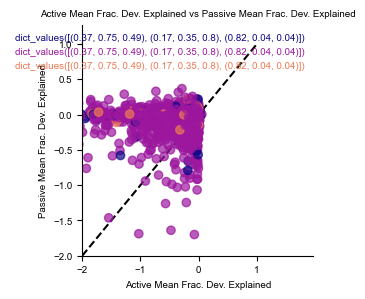

In [13]:
#get dataset cell types
cell_types = {
                0: 'pyr',
                1: 'som',
                2: 'pv',
            }
cell_labels = []
# Loop over each dataset in the results dictionary
for dataset_key, dataset in results_pre.items():
    # if significant_neurons and dataset_key in significant_neurons:
    #             cell_ids = significant_neurons[dataset_key][0]
    # else:
    cell_ids = range(len(dataset['celltype_array']))  # Default to all cells
    cell_labels.extend([cell_types[dataset['celltype_array'][i]] for i in cell_ids])
    
plotter.scatter_model_dev_comparison(mean_frac_dev_plotting_passive,mean_frac_dev_plotting,  cell_labels,measure_string = 'Active Mean Frac. Dev. Explained', measure_string2='Passive Mean Frac. Dev. Explained', plot_lims_neg = -2, minmax = (-2,1))

In [17]:
import scipy
def load_sound_opto_data_test(dir, set_diff = True, exclude=None):
        """
        Loads neuron IDs and their modulation indices based on the provided directories and optogenetic condition.

        Parameters:
        dir: str
            Directory for opto data.


        Returns:
        significant_neurons: dict
            A dictionary mapping mouse_date to its significant neurons.
        mod_index_neurons: dict
            A dictionary mapping mouse_date to its corresponding modulation index for significant neurons.
        mouse_dates: list
            A list of mouse dates after formatting.
        """
        
        # Load the condition_array_trials structure
        mat_data = scipy.io.loadmat(os.path.join(dir, 'opto.mat'))
        opto = mat_data['opto'][0][0]
        opto = data_handler.unwrap_matlab(opto)

        mat_data = scipy.io.loadmat(os.path.join(dir, 'sound.mat'))
        sound = mat_data['sound'][0][0]
        sound = data_handler.unwrap_matlab(sound)

            # Load the info structure to get mouse_date

        mat_data = scipy.io.loadmat(os.path.join(dir, 'info.mat'))
        info = mat_data['info'][0][0]    

        # Assuming your mouse_date structure is loaded as a numpy array
        mouse_dates = [
            item[0].replace('\\', '_').replace('/', '_')  # Replace slashes with underscores for consistency
            for item in info['mouse_date'][0]
        ]

        # ---- NEW: process exclusion argument ----
        if exclude is not None:
            # convert single value to list
            if not isinstance(exclude, (list, tuple)):
                exclude = [exclude]
            exclude_indices = []
            for ex in exclude:
                if isinstance(ex, int):
                    exclude_indices.append(ex)
                elif isinstance(ex, str) and ex in mouse_dates:
                    exclude_indices.append(mouse_dates.index(ex))
            # remove duplicates
            exclude_indices = list(set(exclude_indices))
        else:
            exclude_indices = []

        if len(exclude_indices) > 0:

            keep_idx = [i for i in range(len(mouse_dates))
                        if i not in exclude_indices]
            print(keep_idx)

            mouse_dates = [mouse_dates[i] for i in keep_idx]

            # n_datasets = len(keep_idx) + len(exclude_indices)  # original number
            orig_n = len(mouse_dates) + len(exclude_indices)
            for field in opto.dtype.names:
                arr = opto[field]

                if not hasattr(arr, "shape"):
                    continue

                if arr.ndim == 2 and arr.shape[0] == orig_n:
                    opto[field] = arr[keep_idx, :]
                elif arr.shape[1] == orig_n or arr.shape[1] == orig_n-1:
                    opto[field] = arr[:, keep_idx]

            for field in sound.dtype.names:
                arr = sound[field]

                if not hasattr(arr, "shape"):
                    continue

                if arr.ndim == 2 and arr.shape[0] == orig_n:
                    sound[field] = arr[keep_idx, :]
                elif arr.shape[1] == orig_n or arr.shape[1] == orig_n-1:
                    sound[field] = arr[:, keep_idx]
           

        significant_neurons = {}
        mod_indices = {}
        #create fields for sound pos and neg
        sound_separated = {
            'sig_cells_pos': np.empty((1, len(mouse_dates)), dtype=object),
            'sig_cells_neg': np.empty((1, len(mouse_dates)), dtype=object)
        }
        # Iterate over mouse_dates and map to corresponding neurons in sig_cells by index
        for idx, mouse_date in enumerate(mouse_dates):
            
            # ---- NEW: skip excluded datasets ----
            # if idx in exclude_indices:
            #     continue

            significant_neurons[mouse_date] = {}
            opto_neurons = opto['sig_cells'][idx,0]-1 # Adjust for MATLAB indexing
            sound_neurons = sound['sig_cells'][0,idx]-1 # Adjust for MATLAB indexing

            mod_indices[mouse_date] = {}

            for context in range(opto['mod'].shape[1]):
                mod_indices[mouse_date][context] = {}   # initialize context dictionary
                mod_indices[mouse_date][context]['opto'] = opto['mod'][idx, context]
            for context in range(sound['mod'].shape[1]):
                if context not in mod_indices[mouse_date]:
                    mod_indices[mouse_date][context] = {}
                mod_indices[mouse_date][context]['sound'] = sound['mod'][idx, context]

            #get total nuerons
            all_neurons = list(range(opto['mod'][idx,0].shape[0]))#range(0,opto['mod'][idx,0].shape[0])
            

            # get modulation values for sound (assuming context 0 for sound)
            sig_cells = sound_neurons

            mod0 = sound['mod'][idx,0]
            mod1 = sound['mod'][idx,1]

            sound_sig_pos = [
                n for n in sig_cells
                if mod0[n] > 0 and mod1[n] > 0
            ]

            sound_sig_neg = [
                n for n in sig_cells
                if mod0[n] < 0 and mod1[n] < 0
            ]

            if set_diff:
                sound_only = list(set(sound_neurons) - set(opto_neurons))
                opto_only  = list(set(opto_neurons) - set(sound_neurons))
            else:
                sound_only = list(sound_neurons)
                opto_only  = list(opto_neurons)

            # Now apply sign split WITHIN the set-diff result

            sound_pos_only = sound_sig_pos
            sound_neg_only = sound_sig_neg

            significant_neurons[mouse_date]['opto'] = opto_only
            significant_neurons[mouse_date]['sound'] = sound_only
            significant_neurons[mouse_date]['sound_pos'] = sound_pos_only
            significant_neurons[mouse_date]['sound_neg'] = sound_neg_only
            significant_neurons[mouse_date]['both'] = list(set(opto_neurons).intersection(set(sound_neurons)))
            significant_neurons[mouse_date]['unmod'] = list(set(all_neurons) - set(opto_neurons) - set(sound_neurons))

            #put sound pos and neg into sound
            sound_separated['sig_cells_pos'][0,idx] = sound_sig_pos
            sound_separated['sig_cells_neg'][0,idx] = sound_sig_neg

        return opto, sound, mouse_dates, significant_neurons, mod_indices,sound_separated

opto, sound, mouse_dates, significant_neurons, mod_indices,sound_separated = load_sound_opto_data_test('W:\Connie/results\Bassi2025\data', set_diff = True,exclude = "HA10-1L_2023-04-17")# exclude = "HE1-00_2023-05-30")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [19]:
#load opto/sound neurons
opto, sound, mouse_dates, significant_neurons, mod_indices = data_handler.load_sound_opto_data('W:\Connie/results\Bassi2025\data', set_diff = True, exclude = ["HA10-1L_2023-04-17", "HE1-00_2023-05-30"])# exclude = "HE1-00_2023-05-30")

AttributeError: 'numpy.void' object has no attribute 'keys'

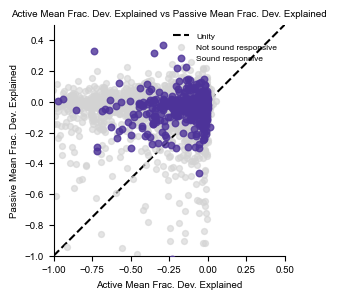

(array([-0.05787074, -0.30997016, -0.31515263, ..., -0.22172623,
        -0.04536044, -0.14334109]),
 array([-0.00867286,  0.00446482, -0.00607146, ...,  0.08676029,
        -0.0010886 , -0.0546423 ]),
 array([ True, False, False, ..., False, False, False]))

In [18]:
def scatter_dev_active_passive_sound_sig(
    dev_active_by_key,
    dev_passive_by_key,
    datasets,
    sound,
    sig_type = 'sig_cells',
    measure_string='Active',
    measure_string2='Passive',
    plot_lims=None,
    plot_lims_neg=None,
    save_path=None,
    sig_index_base=0
):
    """
    dev_active_by_key[key] = array, shape (n_neurons,)
    dev_passive_by_key[key] = array, shape (n_neurons,)

    sound[sig_type][0, dataset_idx] = indices of sound-responsive neurons
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})
    mpl.rcParams['pdf.fonttype'] = 42

    all_active = []
    all_passive = []
    all_is_sig = []

    for dataset_idx, (animalID, date, server) in enumerate(datasets):
        key = f'{animalID}_{date}'

        active_vals = np.asarray(dev_active_by_key[key]).squeeze()
        passive_vals = np.asarray(dev_passive_by_key[key]).squeeze()

        assert active_vals.shape == passive_vals.shape

        n_neurons = active_vals.shape[0]

        sig_cells = np.asarray(sound[sig_type][0, dataset_idx]).squeeze()

        if sig_cells.size == 0:
            sig_cells = np.array([], dtype=int)
        else:
            sig_cells = sig_cells.astype(int)

        # convert MATLAB 1-based indices to Python 0-based if needed
        if sig_index_base == 1:
            sig_cells = sig_cells - 1

        is_sig = np.zeros(n_neurons, dtype=bool)
        sig_cells = sig_cells[(sig_cells >= 0) & (sig_cells < n_neurons)]
        is_sig[sig_cells] = True

        all_active.append(active_vals)
        all_passive.append(passive_vals)
        all_is_sig.append(is_sig)

    active_plot = np.concatenate(all_active)
    passive_plot = np.concatenate(all_passive)
    is_sig_plot = np.concatenate(all_is_sig)

    good = (
        ~np.isnan(active_plot) &
        ~np.isnan(passive_plot)
    )

    active_plot = active_plot[good]
    passive_plot = passive_plot[good]
    is_sig_plot = is_sig_plot[good]

    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    if plot_lims is None:
        max_lim = np.nanmax([active_plot.max(), passive_plot.max(), 0.5])
    else:
        max_lim = plot_lims

    min_lim = 0 if plot_lims_neg is None else plot_lims_neg

    ax.plot(
        [min_lim, max_lim],
        [min_lim, max_lim],
        '--',
        color='black',
        zorder=1,
        label='Unity'
    )

    # non-sound-responsive cells
    ax.scatter(
        active_plot[~is_sig_plot],
        passive_plot[~is_sig_plot],
        c='lightgray',
        alpha=0.6,
        s=18,
        zorder=2,
        label='Not sound responsive'
    )

    # sound-responsive cells
    ax.scatter(
        active_plot[is_sig_plot],
        passive_plot[is_sig_plot],
        c='#4D3399', #purple
        alpha=0.8,
        s=22,
        zorder=3,
        label='Sound responsive'
    )

    ax.set_xlabel(measure_string, fontsize=7)
    ax.set_ylabel(measure_string2, fontsize=7)
    ax.set_title(f'{measure_string} vs {measure_string2}', fontsize=7)

    ax.set_xlim(min_lim, max_lim)
    ax.set_ylim(min_lim, max_lim)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)

    ax.legend(frameon=False, fontsize=6)

    new_rc_params = {
        'text.usetex': False,
        'svg.fonttype': 'none'
    }
    plt.rcParams.update(new_rc_params)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', format='pdf')

    plt.show()

    return active_plot, passive_plot, is_sig_plot

scatter_dev_active_passive_sound_sig(mean_frac_dev_by_key, mean_frac_dev_by_key_passive, datasets, sound_separated,sig_type = 'sig_cells_pos', measure_string = 'Active Mean Frac. Dev. Explained', measure_string2='Passive Mean Frac. Dev. Explained',  plot_lims = 0.5, plot_lims_neg = -1)

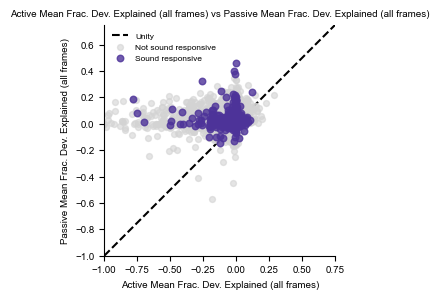

(array([-0.03814499, -0.09186077, -0.04516037, ..., -0.01398579,
        -0.0510822 , -0.05410964]),
 array([-0.00491516,  0.00308191,  0.00258705, ...,  0.08368975,
        -0.00520413,  0.03060282]),
 array([ True, False, False, ..., False, False, False]))

In [78]:
#plot dev explained using all frames!
mean_frac_dev_by_key_all = {}
mean_frac_dev_by_key_passive_all = {}

for ds in datasets:
    animal, date, server = ds  # server ignored for lookup

    key = f"{animal}_{date}"

    mean_frac_dev_by_key_all[key] = results_pre[key]['mean_dev_0']
    mean_frac_dev_by_key_passive_all[key] = results_pre[key]['mean_dev_1']


scatter_dev_active_passive_sound_sig(
    mean_frac_dev_by_key_all,
    mean_frac_dev_by_key_passive_all,
    datasets,
    sound_separated,
    sig_type='sig_cells_pos',
    plot_lims=0.75,
    plot_lims_neg=-1,
    measure_string = 'Active Mean Frac. Dev. Explained (all frames)', 
    measure_string2='Passive Mean Frac. Dev. Explained (all frames)'
)

In [20]:
#LOAD RUNNING PREDICTORS AND RESPONSE FOR EXAMPLE DATASET
### settings
example_dataset = mouse_dates_keys[0]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')
fold_number = 0
model_type = 'GLM_running'
running_trace_mode = "raw_velocity_split" #"raw_velocity" or "grouped_predictors"

##load data
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")

response_matrix = predictorfun.load_test_response(path)
running_predictors = predictorfun.load_running_predictors(path)

model_output = results_pre[example_dataset]["model_output_running_active"]
fold_output = model_output[fold_number]
y_pred = fold_output["y_pred"]
frac_dev_expl = fold_output["frac_dev_expl"]

predictorfun.validate_response_prediction_shapes(response_matrix, y_pred)

running_group_summaries = predictorfun.summarize_running_predictors_for_display(
    running_predictors,
    group_mode="4_groups"
)

velocity = predictorfun.load_velocity(path)
velocity_dict = predictorfun.split_velocity(velocity)
velocity_display_traces = predictorfun.make_raw_velocity_display_traces(
    velocity_dict,
    mode=running_trace_mode
)

top_positive_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    frac_dev_expl,
    n_examples=4
)

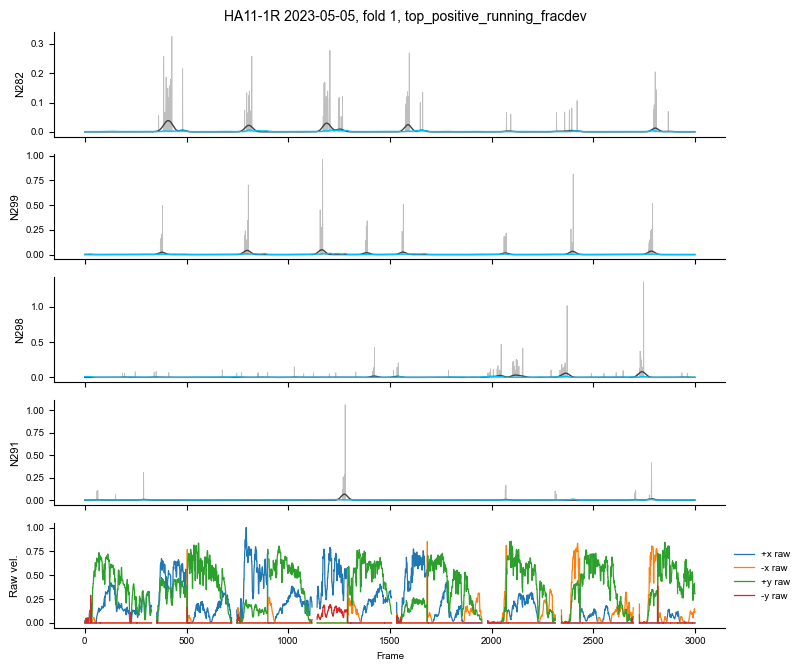

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_raw_velocity_split_HA11-1R_fold1_0to2999.pdf


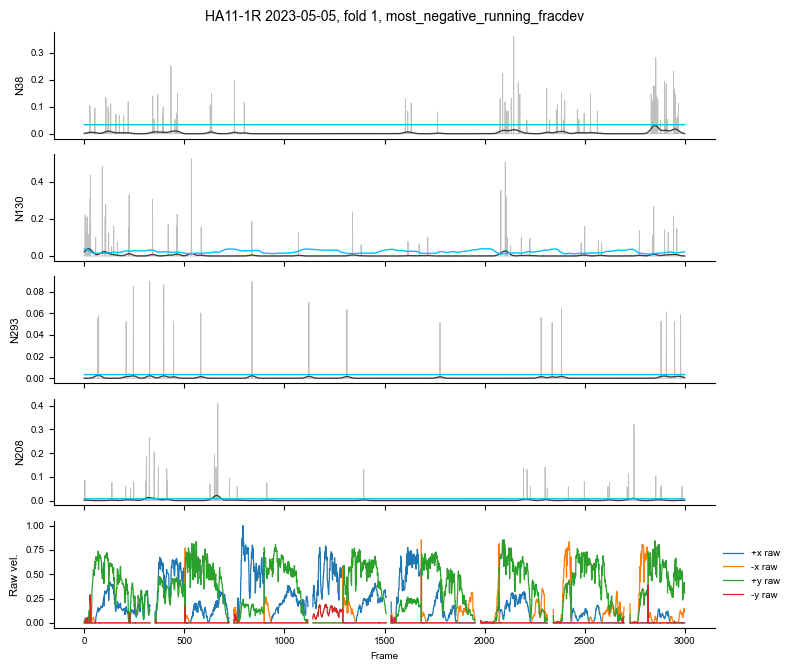

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_raw_velocity_split_HA11-1R_fold1_0to2999.pdf


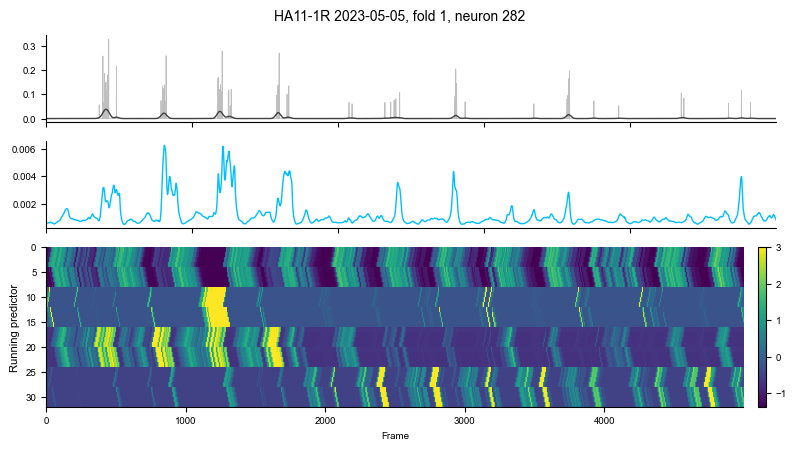

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_heatmap_N282_HA11-1R_2023-05-05_fold1_0to4999.pdf


(<Figure size 800x450 with 4 Axes>,
 array([<Axes: >, <Axes: >,
        <Axes: xlabel='Frame', ylabel='Running predictor'>], dtype=object),
 'W:\\Connie/results\\Bassi2025\\glm_coupling/example_predictions_running_predictors\\top_positive_running_fracdev_heatmap_N282_HA11-1R_2023-05-05_fold1_0to4999.pdf')

In [23]:
#PLOT EXAMPLE TRACES FOR TOP AND BOTTOM NEURONS
supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)
plot_windows = [(0,3000)]

for frame_start, frame_end in plot_windows:
    plotter.plot_running_glm_neuron_group(
        neuron_ids=top_positive_neurons,
        frame_start=frame_start,
        frame_end=frame_end,
        response_matrix=response_matrix,
        y_pred=y_pred,
        frac_dev_expl=frac_dev_expl,
        running_trace_mode=running_trace_mode,
        running_group_summaries=running_group_summaries,
        velocity_display_traces=velocity_display_traces,
        supp_figure_dir=supp_figure_dir,
        animalID=animalID,
        date=date,
        model_type=model_type,
        fold_number=fold_number,
        label="top_positive_running_fracdev",
        plot_real_activity = True #plot deconvolved or not
    )

    plotter.plot_running_glm_neuron_group(
        neuron_ids=negative_neurons,
        frame_start=frame_start,
        frame_end=frame_end,
        response_matrix=response_matrix,
        y_pred=y_pred,
        frac_dev_expl=frac_dev_expl,
        running_trace_mode=running_trace_mode,
        running_group_summaries=running_group_summaries,
        velocity_display_traces=velocity_display_traces,
        supp_figure_dir=supp_figure_dir,
        animalID=animalID,
        date=date,
        model_type=model_type,
        fold_number=fold_number,
        label="most_negative_running_fracdev",
        plot_real_activity = True #plot deconvolved or not
    )

plotter.plot_single_neuron_predictor_heatmap(
    neuron_idx=top_positive_neurons[0],
    frame_start=0,
    frame_end=5000,
    response_matrix=response_matrix,
    y_pred=y_pred,
    frac_dev_expl=frac_dev_expl,
    running_predictors=running_predictors,
    supp_figure_dir=supp_figure_dir,
    animalID=animalID,
    date=date,
    model_type=model_type,
    fold_number=fold_number,
    label="top_positive_running_fracdev",
)

In [81]:
#settings
example_dataset = mouse_dates_keys[0]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")
# -----------------------------
# Load neural response
# -----------------------------

response_path = os.path.join(path, 'combined_response.mat')
response = scipy.io.loadmat(response_path)
response_matrix = np.asarray(response['combined_response'])  # neurons x frames

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = np.asarray(fold_output['y_pred'])  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

# -----------------------------
# Load convolved running predictors
# -----------------------------

predictor_path = os.path.join(path, 'behav_big_matrix.mat')
pred_file = scipy.io.loadmat(predictor_path)

# path = predictorfun.get_fold_test_path(server, animalID, date, "GLM_running", fold_number)

# response_matrix = predictorfun.load_test_response(path)
# running_predictors = predictorfun.load_running_predictors(path)

model_output = results_pre[example_dataset]["model_output_running_active"]
fold_output = model_output[fold_number]
y_pred = fold_output["y_pred"]
frac_dev_expl = fold_output["frac_dev_expl"]

running_trace_mode = "raw_velocity_split"

# Choose whether to also make single-neuron heatmaps of all 32 convolved predictors
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# Use 4 grouped convolved traces or 8 grouped convolved traces
# Only affects running_trace_mode = "grouped_predictors"
predictor_group_mode = "4_groups"


# -----------------------------
# Load raw velocity ONLY if needed
# -----------------------------

running_predictors = np.asarray(pred_file['behav_big_matrix'])  # expected 32 x frames

# If saved as frames x predictors, transpose it
if running_predictors.shape[0] != 32 and running_predictors.shape[1] == 32:
    running_predictors = running_predictors.T

if running_predictors.shape[0] != 32:
    raise ValueError(
        f"Expected running_predictors to be 32 x frames, got {running_predictors.shape}"
    )

velocity = None
x_velocity_raw = None
y_velocity_raw = None
pos_x_velocity_raw = None
neg_x_velocity_raw = None
pos_y_velocity_raw = None
neg_y_velocity_raw = None

if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
    velocity_path = os.path.join(path, 'velocity.mat')

    if not os.path.exists(velocity_path):
        raise FileNotFoundError(f"Could not find velocity.mat at: {velocity_path}")

    velocity_file = scipy.io.loadmat(velocity_path)

    if 'velocity' not in velocity_file:
        raise KeyError(
            f"'velocity' not found in velocity.mat. "
            f"Available keys: {list(velocity_file.keys())}"
        )

    velocity = np.asarray(velocity_file['velocity']).squeeze()

    # Ensure velocity is 2 x frames
    if velocity.ndim != 2:
        raise ValueError(f"Expected velocity to be 2D, got shape {velocity.shape}")

    if velocity.shape[0] != 2 and velocity.shape[1] == 2:
        velocity = velocity.T

    if velocity.shape[0] != 2:
        raise ValueError(f"Expected velocity to be 2 x frames, got {velocity.shape}")

    x_velocity_raw = velocity[0, :]
    y_velocity_raw = velocity[1, :]

    pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
    neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

    pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
    neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

    x_overlap = np.sum((pos_x_velocity_raw > 0) & (neg_x_velocity_raw > 0))
    y_overlap = np.sum((pos_y_velocity_raw > 0) & (neg_y_velocity_raw > 0))

    print("velocity shape, x/y x frames:", velocity.shape)
    print(f"Raw +x and -x overlap frames: {x_overlap}")
    print(f"Raw +y and -y overlap frames: {y_overlap}")

# predictorfun.validate_response_prediction_shapes(response_matrix, y_pred)

running_group_summaries = predictorfun.summarize_running_predictors_for_display(
    running_predictors,
    group_mode="4_groups"
)

velocity = predictorfun.load_velocity(path)
velocity_dict = predictorfun.split_velocity(velocity)
velocity_display_traces = predictorfun.make_raw_velocity_display_traces(
    velocity_dict,
    mode="raw_velocity_split"
)

top_neurons, negative_neurons = predictorfun.get_top_and_bottom_neurons(
    frac_dev_expl,
    n_examples=4
)

velocity shape, x/y x frames: (2, 22956)
Raw +x and -x overlap frames: 0
Raw +y and -y overlap frames: 0


AttributeError: 'GLMPredictorProcessor' object has no attribute 'summarize_running_predictors_for_display'

In [59]:
import numpy as np
import matplotlib.pyplot as plt


def mean_response_per_key(aligned_neural):
    """
    aligned_neural[key][fold] has shape:
        trials x neurons x frames

    Returns:
        key_means[key] with shape:
            neurons x frames
    """

    key_means = {}

    for key, folds in aligned_neural.items():

        fold_means = []

        # works whether folds is a list or dict
        fold_iter = folds.values() if isinstance(folds, dict) else folds

        for fold_data in fold_iter:
            # mean over trials
            # trials x neurons x frames -> neurons x frames
            fold_mean = np.nanmean(fold_data, axis=0)
            fold_means.append(fold_mean)

        # mean over folds
        # folds x neurons x frames -> neurons x frames
        key_means[key] = np.nanmean(np.stack(fold_means, axis=0), axis=0)

    return key_means

def plot_neuron_for_key(true_means, pred_means, key, neuron_idx, frame_times=None):
    """
    Plots true vs predicted mean response for one neuron from one key.
    """

    true_resp = true_means[key][neuron_idx, :]
    pred_resp = pred_means[key][neuron_idx, :]

    if frame_times is None:
        x = np.arange(true_resp.shape[0])
        xlabel = "Frame"
    else:
        x = frame_times
        xlabel = "Time"

    plt.figure(figsize=(6, 4))
    plt.plot(x, true_resp, label="True")
    plt.plot(x, pred_resp, label="Predicted")

    plt.xlabel(xlabel)
    plt.ylabel("Mean response")
    plt.title(f"{key} | neuron {neuron_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()

import numpy as np
import matplotlib.pyplot as plt


def plot_population_mean_across_keys(
    true_means,
    pred_means,
    keys=None,
    frame_times=None,
    error="sem",
    cell_indices_by_dataset=None,
    cell_index_col=0,
    dataset_axis_matches_keys=True,
    title="Population mean across datasets",
    event_onset = [6, 38, 70],
    ylims = (0,0.007)
):
    """
    Plots true vs predicted mean response across datasets.

    Parameters
    ----------
    true_means : dict
        true_means[key] has shape neurons x frames

    pred_means : dict
        pred_means[key] has shape neurons x frames

    keys : list, optional
        Dataset keys to include. If None, uses all keys in true_means.

    frame_times : array-like, optional
        Time values for x-axis. If None, uses frame number.

    error : {"sem", "std", None}
        Error band across datasets.

    cell_indices_by_dataset : array-like, optional
        Object where cell_indices_by_dataset[dataset_idx, cell_index_col]
        gives neuron indices to use for that dataset.

        Example:
            sig_cells[dataset_idx, 0]

        If None, all neurons are used.

    cell_index_col : int
        Column of cell_indices_by_dataset containing the cell indices.
        Default is 0.

    dataset_axis_matches_keys : bool
        If True, assumes dataset_idx is the position of the key in keys.
        So for keys[0], uses sig_cells[0, 0].
        For keys[1], uses sig_cells[1, 0], etc.

    title : str
        Plot title.
    """

    if keys is None:
        keys = list(true_means.keys())

    true_by_dataset = []
    pred_by_dataset = []
    used_keys = []
    n_cells_used = []

    for dataset_idx, key in enumerate(keys):

        true_data = true_means[key]  # neurons x frames
        pred_data = pred_means[key]  # neurons x frames

        if cell_indices_by_dataset is not None:
            if dataset_axis_matches_keys:
                cell_idx = cell_indices_by_dataset[cell_index_col, dataset_idx] -1  # convert from MATLAB 1-based to Python 0-based
            else:
                # useful if key itself is the dataset number
                cell_idx = cell_indices_by_dataset[key, cell_index_col] -1  # convert from MATLAB 1-based to Python 0-based

            cell_idx = np.asarray(cell_idx).astype(int)

            # skip dataset if no cells
            if len(cell_idx) == 0:
                continue

            true_data = true_data[cell_idx, :]
            pred_data = pred_data[cell_idx, :]

        # average over selected neurons
        # neurons x frames -> frames
        true_pop = np.nanmean(true_data, axis=0)
        pred_pop = np.nanmean(pred_data, axis=0)

        true_by_dataset.append(true_pop)
        pred_by_dataset.append(pred_pop)
        used_keys.append(key)
        n_cells_used.append(true_data.shape[0])

    # datasets x frames
    true_by_dataset = np.stack(true_by_dataset, axis=0)
    pred_by_dataset = np.stack(pred_by_dataset, axis=0)

    # mean across datasets
    true_mean = np.nanmean(true_by_dataset, axis=0)
    pred_mean = np.nanmean(pred_by_dataset, axis=0)

    if error == "sem":
        true_err = np.nanstd(true_by_dataset, axis=0, ddof=1) / np.sqrt(true_by_dataset.shape[0])
        pred_err = np.nanstd(pred_by_dataset, axis=0, ddof=1) / np.sqrt(pred_by_dataset.shape[0])
    elif error == "std":
        true_err = np.nanstd(true_by_dataset, axis=0, ddof=1)
        pred_err = np.nanstd(pred_by_dataset, axis=0, ddof=1)
    elif error is None:
        true_err = None
        pred_err = None
    else:
        raise ValueError("error must be 'sem', 'std', or None")

    if frame_times is None:
        x = np.arange(true_mean.shape[0])
        xlabel = "Frame"
    else:
        x = frame_times
        xlabel = "Time"

    plt.figure(figsize=(6, 4))

    plt.plot(x, true_mean, label="True")
    plt.plot(x, pred_mean, label="Predicted")
    

    if true_err is not None:
        plt.fill_between(
            x,
            true_mean - true_err,
            true_mean + true_err,
            alpha=0.2
        )
        plt.fill_between(
            x,
            pred_mean - pred_err,
            pred_mean + pred_err,
            alpha=0.2
        )

    
    ax = plt.gca()
    for event in event_onset:
        ax.axvline(x=event, color='k', linestyle=(0, (10.5,6.8)), alpha=1,lw=0.7)

    if ylims is not None:
        ax.set(ylim=(ylims))

    plt.xlabel(xlabel)
    plt.ylabel("Mean response")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "true_by_dataset": true_by_dataset,
        "pred_by_dataset": pred_by_dataset,
        "true_mean": true_mean,
        "pred_mean": pred_mean,
        "used_keys": used_keys,
        "n_cells_used": n_cells_used
    }

true_means = mean_response_per_key(aligned_neural_true)
pred_means = mean_response_per_key(aligned_neural_pred)

# plot_neuron_for_key(
#     true_means=true_means,
#     pred_means=pred_means,
#     key="HA11-1R_2023-05-05",
#     neuron_idx=10
# )

plot_population_mean_across_keys(
    true_means=true_means,
    pred_means=pred_means,
    error="sem",
    cell_indices_by_dataset=sound['sig_cells'],  # example of how to pass sig cells to only plot those
    cell_index_col=0,
    ylims = (0,0.01),
    title = 'Population Mean across datasets (active)'
)


true_means_passive = mean_response_per_key(aligned_neural_true_passive)
pred_means_passive = mean_response_per_key(aligned_neural_pred_passive)


plot_population_mean_across_keys(
    true_means=true_means_passive,
    pred_means=pred_means_passive,
    error="sem",
    cell_indices_by_dataset=sound['sig_cells'],  # example of how to pass sig cells to only plot those
    cell_index_col=0,
    ylims = (0,0.01),
    title = 'Population Mean across datasets (passive)'
)

IndexError: index 387 is out of bounds for axis 0 with size 386

velocity shape, x/y x frames: (2, 22956)
Raw +x and -x overlap frames: 0
Raw +y and -y overlap frames: 0
Path: V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_running/VR_1/test
running_trace_mode: raw_velocity_split
response_matrix shape, neurons x frames: (385, 22956)
y_pred shape, frames x neurons: (22956, 385)
running_predictors shape, predictors x frames: (32, 22956)
frac_dev_expl shape: (385,)
Smoothed rate sigma: 0.5 sec = 15.24 frames

Top positive running FDE neurons:
Neuron 282: FDE = 0.170
Neuron 299: FDE = 0.165
Neuron 298: FDE = 0.161
Neuron 291: FDE = 0.148

Most negative running FDE neurons:
Neuron 38: FDE = -2.649
Neuron 130: FDE = -1.154
Neuron 293: FDE = -1.134
Neuron 208: FDE = -1.121


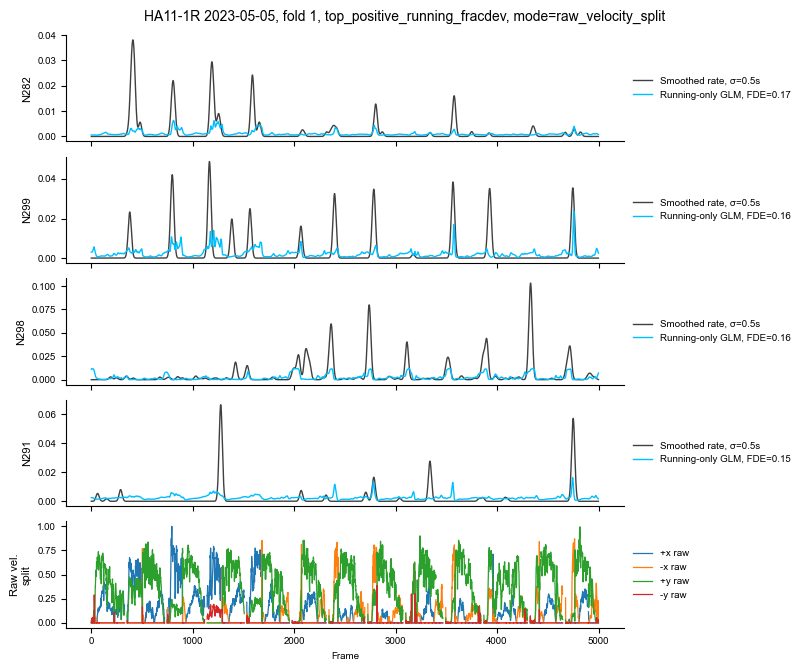

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_raw_velocity_split_HA11-1R_2023-05-05_GLM_running_fold1_0to4999.pdf


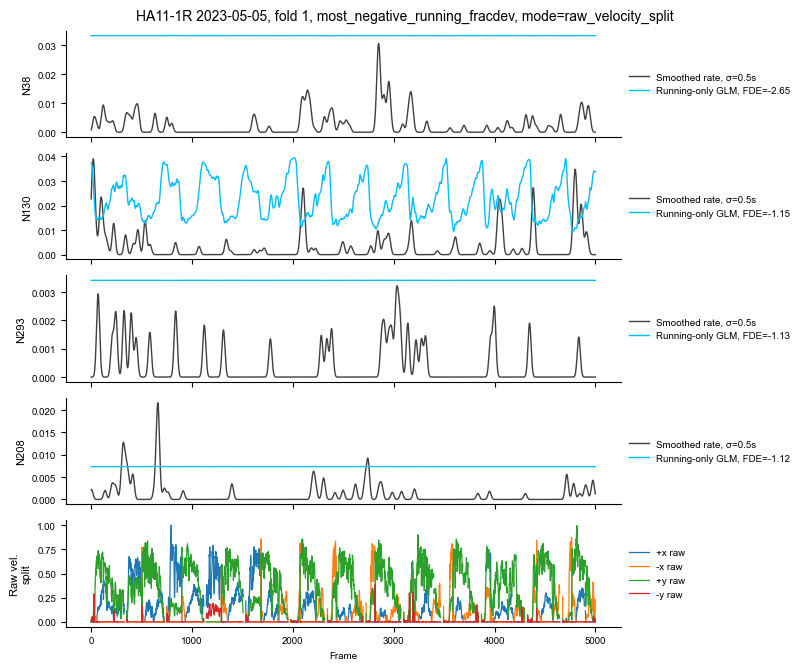

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_raw_velocity_split_HA11-1R_2023-05-05_GLM_running_fold1_0to4999.pdf


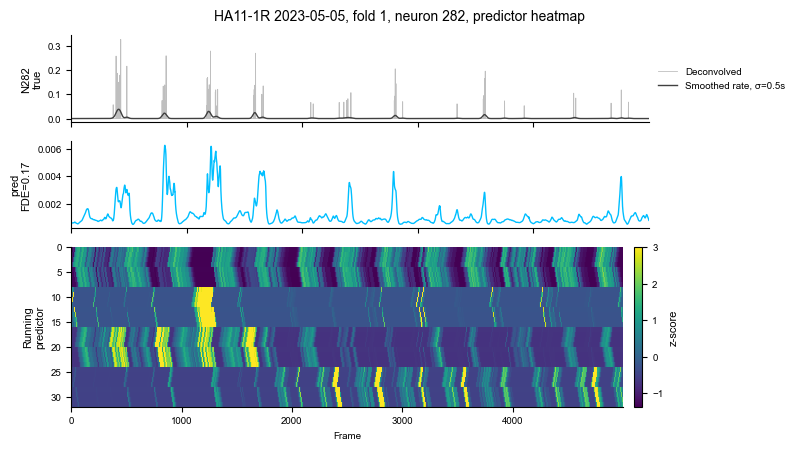

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_heatmap_N282_HA11-1R_2023-05-05_GLM_running_fold1_0to4999.pdf


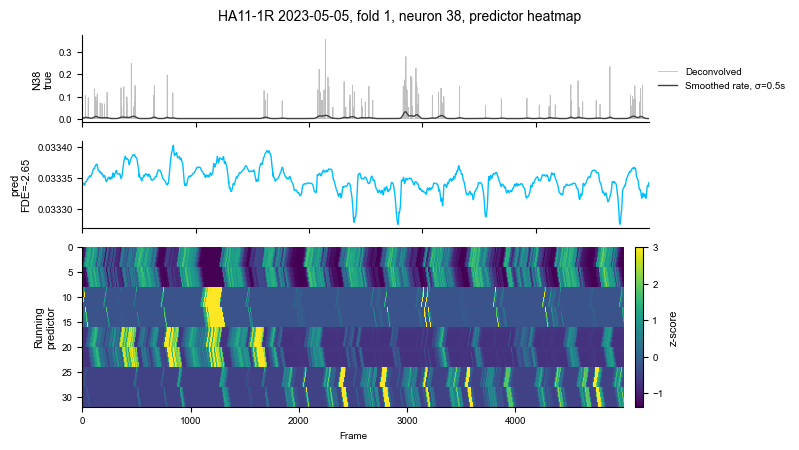

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_heatmap_N38_HA11-1R_2023-05-05_GLM_running_fold1_0to4999.pdf


In [86]:
# Plot running-only GLM predictions, true deconvolved activity, smoothed event rate,
# and either convolved running predictors or raw velocity traces.
#
# Assumptions:
# - combined_response.mat contains "combined_response" with shape neurons x frames
# - behav_big_matrix.mat contains "behav_big_matrix" with shape 32 predictors x frames
# - velocity.mat contains "velocity" with shape 2 x frames:
#       velocity[0, :] = x velocity
#       velocity[1, :] = y velocity
# - y_pred has shape frames x neurons
# - frac_dev_expl has shape neurons

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Settings
# -----------------------------

example_dataset = mouse_dates_keys[0]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")

supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)

n_examples = 4
plot_windows = [(0, 5000)]  # examples: [(0,1000), (1000,2000), (2000,3000)]

# Choose what the BOTTOM PANEL shows:
# "grouped_predictors" = convolved +y, -y, +x, -x predictor summaries
# "raw_velocity" = raw abs(x), abs(y)
# "raw_velocity_split" = raw +x, -x, +y, -y
# running_trace_mode = "grouped_predictors"
# running_trace_mode = "raw_velocity"
running_trace_mode = "raw_velocity_split"

# Choose whether to also make single-neuron heatmaps of all 32 convolved predictors
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# Use 4 grouped convolved traces or 8 grouped convolved traces
# Only affects running_trace_mode = "grouped_predictors"
predictor_group_mode = "4_groups"
# predictor_group_mode = "8_groups"

# -----------------------------
# Helper functions
# -----------------------------

def zscore_for_display(x, axis=1, eps=1e-12):
    """
    Display-only z-score.
    For predictors x frames, use axis=1 to z-score each predictor over time.
    """
    x = np.asarray(x).astype(float).copy()
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sigma = np.nanstd(x, axis=axis, keepdims=True)
    sigma[sigma < eps] = 1.0
    return (x - mu) / sigma


def minmax_for_display(x, eps=1e-12):
    """
    Display-only min-max scaling to 0-1.
    """
    x = np.asarray(x).astype(float).copy()
    x = x - np.nanmin(x)

    denom = np.nanmax(x)
    if denom < eps:
        denom = 1.0

    return x / denom


def make_plot_frames(frame_start, frame_end, max_frame):
    frames = np.arange(frame_start, min(frame_end, max_frame))

    if len(frames) == 0:
        raise ValueError(
            f"No frames to plot. frame_start={frame_start}, "
            f"frame_end={frame_end}, max_frame={max_frame}"
        )

    return frames


# -----------------------------
# Load neural response
# -----------------------------

response_path = os.path.join(path, 'combined_response.mat')
response = scipy.io.loadmat(response_path)
response_matrix = np.asarray(response['combined_response'])  # neurons x frames

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = np.asarray(fold_output['y_pred'])  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

# -----------------------------
# Load convolved running predictors
# -----------------------------

predictor_path = os.path.join(path, 'behav_big_matrix.mat')
pred_file = scipy.io.loadmat(predictor_path)

if 'behav_big_matrix' not in pred_file:
    raise KeyError(
        f"'behav_big_matrix' not found in behav_big_matrix.mat. "
        f"Available keys: {list(pred_file.keys())}"
    )

running_predictors = np.asarray(pred_file['behav_big_matrix'])  # expected 32 x frames

# If saved as frames x predictors, transpose it
if running_predictors.shape[0] != 32 and running_predictors.shape[1] == 32:
    running_predictors = running_predictors.T

if running_predictors.shape[0] != 32:
    raise ValueError(
        f"Expected running_predictors to be 32 x frames, got {running_predictors.shape}"
    )

# -----------------------------
# Load raw velocity ONLY if needed
# -----------------------------

velocity = None
x_velocity_raw = None
y_velocity_raw = None
pos_x_velocity_raw = None
neg_x_velocity_raw = None
pos_y_velocity_raw = None
neg_y_velocity_raw = None

if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
    velocity_path = os.path.join(path, 'velocity.mat')

    if not os.path.exists(velocity_path):
        raise FileNotFoundError(f"Could not find velocity.mat at: {velocity_path}")

    velocity_file = scipy.io.loadmat(velocity_path)

    if 'velocity' not in velocity_file:
        raise KeyError(
            f"'velocity' not found in velocity.mat. "
            f"Available keys: {list(velocity_file.keys())}"
        )

    velocity = np.asarray(velocity_file['velocity']).squeeze()

    # Ensure velocity is 2 x frames
    if velocity.ndim != 2:
        raise ValueError(f"Expected velocity to be 2D, got shape {velocity.shape}")

    if velocity.shape[0] != 2 and velocity.shape[1] == 2:
        velocity = velocity.T

    if velocity.shape[0] != 2:
        raise ValueError(f"Expected velocity to be 2 x frames, got {velocity.shape}")

    x_velocity_raw = velocity[0, :]
    y_velocity_raw = velocity[1, :]

    pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
    neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

    pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
    neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

    x_overlap = np.sum((pos_x_velocity_raw > 0) & (neg_x_velocity_raw > 0))
    y_overlap = np.sum((pos_y_velocity_raw > 0) & (neg_y_velocity_raw > 0))

    print("velocity shape, x/y x frames:", velocity.shape)
    print(f"Raw +x and -x overlap frames: {x_overlap}")
    print(f"Raw +y and -y overlap frames: {y_overlap}")

# -----------------------------
# Print checks
# -----------------------------

print("Path:", path)
print("running_trace_mode:", running_trace_mode)
print("response_matrix shape, neurons x frames:", response_matrix.shape)
print("y_pred shape, frames x neurons:", y_pred.shape)
print("running_predictors shape, predictors x frames:", running_predictors.shape)
print("frac_dev_expl shape:", frac_dev_expl.shape)
print(f"Smoothed rate sigma: {smooth_sigma_sec} sec = {smooth_sigma_frames:.2f} frames")

assert response_matrix.shape[0] == y_pred.shape[1], (
    f"Neuron mismatch: response has {response_matrix.shape[0]} neurons, "
    f"y_pred has {y_pred.shape[1]} neurons"
)

if response_matrix.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: frame mismatch. response has {response_matrix.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

if running_predictors.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: predictor frame mismatch. running_predictors has {running_predictors.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

# -----------------------------
# Create grouped convolved predictor traces
# -----------------------------

running_pred_z = zscore_for_display(running_predictors, axis=1)

predictor_groups_4 = {
    '+y': np.arange(0, 8),
    '-y': np.arange(8, 16),
    '+x': np.arange(16, 24),
    '-x': np.arange(24, 32),
}

predictor_groups_8 = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}

if predictor_group_mode == "4_groups":
    predictor_groups_to_plot = predictor_groups_4
elif predictor_group_mode == "8_groups":
    predictor_groups_to_plot = predictor_groups_8
else:
    raise ValueError("predictor_group_mode must be '4_groups' or '8_groups'")

running_group_summaries = {}

for group_name, group_idx in predictor_groups_to_plot.items():
    group_trace = np.nanmean(np.abs(running_pred_z[group_idx, :]), axis=0)
    running_group_summaries[group_name] = minmax_for_display(group_trace)

# -----------------------------
# Select neurons
# -----------------------------

top_positive_neurons = np.argsort(frac_dev_expl)[::-1][:n_examples]
most_negative_neurons = np.argsort(frac_dev_expl)[:n_examples]

print("\nTop positive running FDE neurons:")
for n in top_positive_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

print("\nMost negative running FDE neurons:")
for n in most_negative_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

# -----------------------------
# Main plotting function
# -----------------------------

def plot_neuron_group(neuron_ids, frame_start, frame_end, label):
    """
    Multi-neuron plot.
    Bottom panel is controlled directly by running_trace_mode.
    """
    max_frame = min(
        response_matrix.shape[1],
        y_pred.shape[0],
        running_predictors.shape[1]
    )

    if running_trace_mode in ["raw_velocity", "raw_velocity_split"]:
        max_frame = min(max_frame, velocity.shape[1])

    frames = make_plot_frames(frame_start, frame_end, max_frame)

    n_rows = len(neuron_ids) + 1

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=(8, 1.35 * n_rows),
        sharex=True
    )

    if n_rows == 1:
        axs = [axs]

    # -----------------------------
    # Neural panels
    # -----------------------------

    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        # ax.plot(
        #     frames,
        #     true_y,
        #     color=[0.75, 0.75, 0.75],
        #     linewidth=0.6,
        #     label='Deconvolved'
        # )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode='nearest'
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.25, 0.25, 0.25],
                linewidth=1.0,
                label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
            )

        ax.plot(
            frames,
            pred_y,
            color='deepskyblue',
            linewidth=1.0,
            label=f'Running-only GLM, FDE={frac_dev_expl[neuron_idx]:.2f}'
        )

        ax.set_ylabel(f'N{neuron_idx}', fontsize=8)
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # -----------------------------
    # Bottom running panel
    # THIS IS WHERE running_trace_mode IS USED
    # -----------------------------

    ax = axs[-1]

    if running_trace_mode == "grouped_predictors":
        for group_name, group_trace in running_group_summaries.items():
            ax.plot(
                frames,
                group_trace[frames],
                linewidth=0.9,
                label=group_name
            )

        ax.set_ylabel('Convolved\npred.', fontsize=8)

    elif running_trace_mode == "raw_velocity":
        abs_x = minmax_for_display(np.abs(x_velocity_raw))
        abs_y = minmax_for_display(np.abs(y_velocity_raw))

        ax.plot(frames, abs_x[frames], linewidth=0.9, label='abs x raw')
        ax.plot(frames, abs_y[frames], linewidth=0.9, label='abs y raw')

        ax.set_ylabel('Raw vel.', fontsize=8)

    elif running_trace_mode == "raw_velocity_split":
        px = minmax_for_display(pos_x_velocity_raw)
        nx = minmax_for_display(neg_x_velocity_raw)
        py = minmax_for_display(pos_y_velocity_raw)
        ny = minmax_for_display(neg_y_velocity_raw)

        ax.plot(frames, px[frames], linewidth=0.9, label='+x raw')
        ax.plot(frames, nx[frames], linewidth=0.9, label='-x raw')
        ax.plot(frames, py[frames], linewidth=0.9, label='+y raw')
        ax.plot(frames, ny[frames], linewidth=0.9, label='-y raw')

        ax.set_ylabel('Raw vel.\nsplit', fontsize=8)

    else:
        raise ValueError(
            "running_trace_mode must be one of: "
            "'grouped_predictors', 'raw_velocity', or 'raw_velocity_split'"
        )

    ax.set_xlabel('Frame')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, fold {fold_number + 1}, {label}, mode={running_trace_mode}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_{running_trace_mode}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frames[0]}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)

# -----------------------------
# Optional heatmap function
# This always plots the 32 convolved predictors from behav_big_matrix.
# It is NOT controlled by running_trace_mode.
# -----------------------------

def plot_single_neuron_predictor_heatmap(neuron_idx, frame_start, frame_end, label):
    max_frame = min(
        response_matrix.shape[1],
        y_pred.shape[0],
        running_predictors.shape[1]
    )

    frames = make_plot_frames(frame_start, frame_end, max_frame)

    pred_display = zscore_for_display(running_predictors[:, frames], axis=1)
    pred_display = np.clip(pred_display, -3, 3)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(8, 4.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 2.2]}
    )

    true_y = response_matrix[neuron_idx, frames]
    pred_y = y_pred[frames, neuron_idx]

    axs[0].plot(
        frames,
        true_y,
        color=[0.75, 0.75, 0.75],
        linewidth=0.6,
        label='Deconvolved'
    )

    if plot_smoothed_rate:
        true_rate = gaussian_filter1d(
            true_y.astype(float),
            sigma=smooth_sigma_frames,
            mode='nearest'
        )

        axs[0].plot(
            frames,
            true_rate,
            color=[0.25, 0.25, 0.25],
            linewidth=1.0,
            label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
        )

        axs[0].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    axs[0].set_ylabel(f'N{neuron_idx}\ntrue', fontsize=8)

    axs[1].plot(
        frames,
        pred_y,
        color='deepskyblue',
        linewidth=1.0
    )
    axs[1].set_ylabel(f'pred\nFDE={frac_dev_expl[neuron_idx]:.2f}', fontsize=8)

    im = axs[2].imshow(
        pred_display,
        aspect='auto',
        interpolation='nearest',
        extent=[frames[0], frames[-1], running_predictors.shape[0], 0]
    )

    axs[2].set_ylabel('Running\npredictor', fontsize=8)
    axs[2].set_xlabel('Frame')

    cbar = plt.colorbar(im, ax=axs[2], fraction=0.025, pad=0.02)
    cbar.set_label('z-score', fontsize=8)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, fold {fold_number + 1}, neuron {neuron_idx}, predictor heatmap',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_heatmap_N{neuron_idx}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frames[0]}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)

# -----------------------------
# Make plots
# -----------------------------

for frame_start, frame_end in plot_windows:
    plot_neuron_group(
        top_positive_neurons,
        frame_start,
        frame_end,
        label='top_positive_running_fracdev'
    )

    plot_neuron_group(
        most_negative_neurons,
        frame_start,
        frame_end,
        label='most_negative_running_fracdev'
    )

if make_heatmaps:
    for frame_start, frame_end in plot_windows[:1]:
        plot_single_neuron_predictor_heatmap(
            top_positive_neurons[0],
            frame_start,
            frame_end,
            label='top_positive_running_fracdev'
        )

        plot_single_neuron_predictor_heatmap(
            most_negative_neurons[0],
            frame_start,
            frame_end,
            label='most_negative_running_fracdev'
        )

Loading from: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
velocity shape, x/y x frames: (2, 25295)
Path: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
response_matrix shape, neurons x frames: (159, 25295)
y_pred shape, frames x neurons: (25295, 159)
running_predictors shape, predictors x frames: (32, 25295)
frac_dev_expl shape: (159,)
Smoothed rate sigma: 0.5 sec = 15.24 frames

Top positive running FDE neurons:
Neuron 76: FDE = 0.132
Neuron 59: FDE = 0.086
Neuron 135: FDE = 0.084
Neuron 58: FDE = 0.068

Most negative running FDE neurons:
Neuron 105: FDE = -0.436
Neuron 121: FDE = -0.433
Neuron 41: FDE = -0.355
Neuron 113: FDE = -0.223


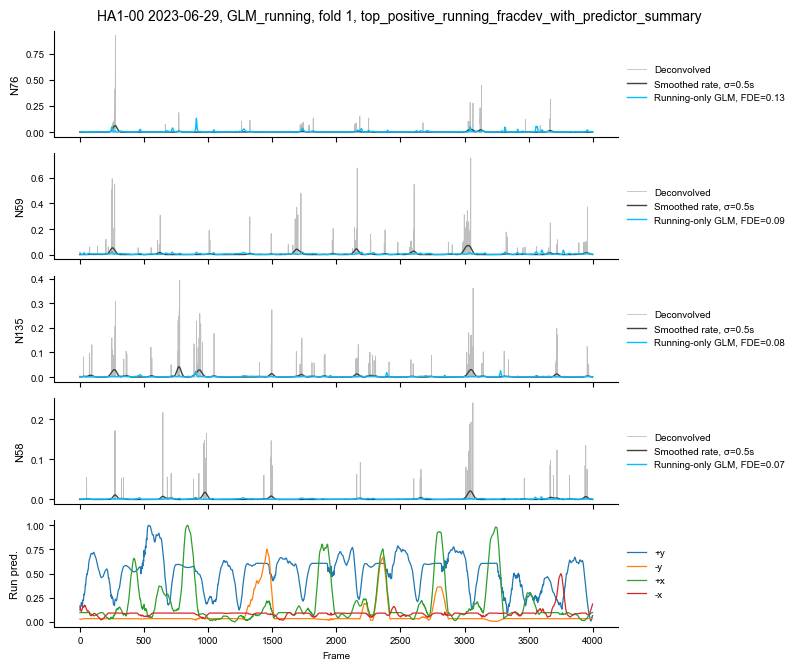

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


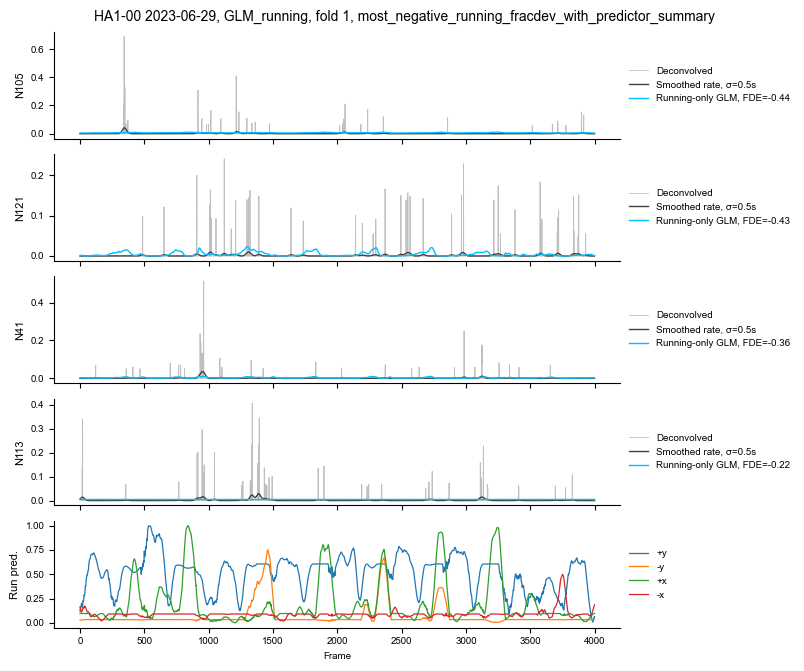

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


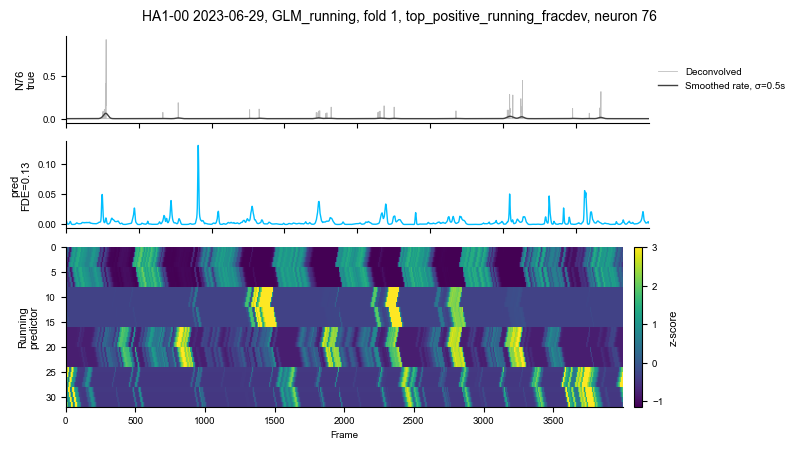

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_heatmap_N76_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


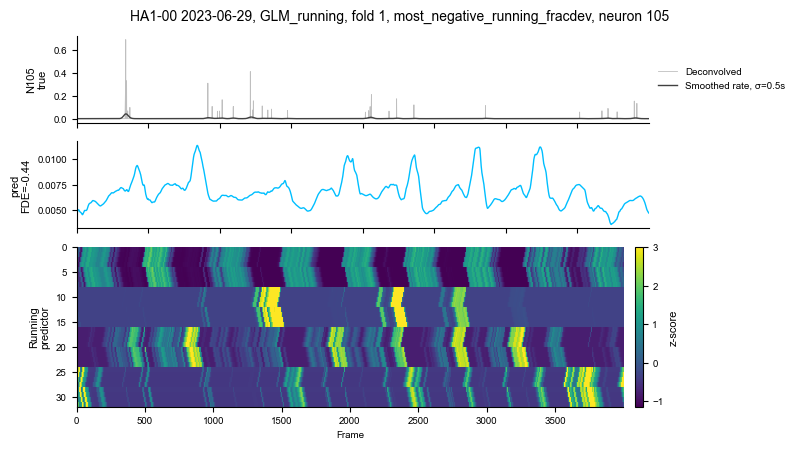

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_heatmap_N105_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


In [81]:
# Plot running-only GLM predictions, true deconvolved activity, smoothed event rate, and running predictors
# Assumptions:
# - behav_big_matrix.mat contains variable "behav_big_matrix" with shape predictors x frames
# - combined_response.mat contains "combined_response" with shape neurons x frames
# - model y_pred has shape frames x neurons
# - frac_dev_expl has shape neurons
# - response/predictor matrices are from the same fold/test directory

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Settings
# -----------------------------

example_dataset = mouse_dates_keys[4]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")

print("Loading from:", path)

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()
y_pred = np.asarray(fold_output['y_pred'])

# -----------------------------
# Load response and behavior
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = np.asarray(response['combined_response'])

behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = np.asarray(behav['behav_the_matrix'])

# -----------------------------
# Load raw velocity
# -----------------------------

velocity_file = scipy.io.loadmat(os.path.join(path, 'velocity.mat'))
velocity = velocity_file['velocity'] # expected shape: 2 x frames

x_velocity_raw = velocity[0, :]
y_velocity_raw = velocity[1, :]

pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

print("velocity shape, x/y x frames:", velocity.shape)


supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)

# Change these if desired
n_examples = 4
plot_windows = [(0, 1000), (1000, 2000), (2000, 3000)]
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# -----------------------------
# Helper functions
# -----------------------------

def zscore_for_display(x, axis=1, eps=1e-12):
    """
    Display-only z-score.
    For predictors x frames, use axis=1 to z-score each predictor over time.
    """
    x = x.astype(float).copy()
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sigma = np.nanstd(x, axis=axis, keepdims=True)
    sigma[sigma < eps] = 1.0
    return (x - mu) / sigma


def minmax_for_display(x, eps=1e-12):
    """
    Display-only min-max scaling to 0-1.
    """
    x = x.astype(float).copy()
    x = x - np.nanmin(x)
    denom = np.nanmax(x)
    if denom < eps:
        denom = 1.0
    return x / denom


def plot_neurons_with_running_summary(neuron_ids, frame_start, frame_end, label):
    """
    Plot true deconvolved activity, smoothed deconvolved rate,
    running-only prediction, and a compact running predictor magnitude trace.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    n_rows = len(neuron_ids) + 1

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=(8, 1.35 * n_rows),
        sharex=True
    )

    if n_rows == 1:
        axs = [axs]

    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        ax.plot(
            frames,
            true_y,
            color=[0.75, 0.75, 0.75],
            linewidth=0.6,
            label='Deconvolved'
        )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode='nearest'
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.25, 0.25, 0.25],
                linewidth=1.0,
                label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
            )

        ax.plot(
            frames,
            pred_y,
            color='deepskyblue',
            linewidth=1.0,
            label=f'Running-only GLM, FDE={frac_dev_expl[neuron_idx]:.2f}'
        )

        ax.set_ylabel(f'N{neuron_idx}', fontsize=8)
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Running predictor summary
    ax = axs[-1]

    for group_name, group_trace in running_group_summaries.items():
        ax.plot(
            frames,
            group_trace[frames],
            linewidth=0.9,
            label=group_name
        )

    ax.set_ylabel('Run pred.\ngroups', fontsize=8)

    # ax.plot(
    #     frames,
    #     running_summary_display[frames],
    #     color=[0.2, 0.2, 0.2],
    #     linewidth=0.9,
    #     label='Running predictor magnitude'
    # )

    ax.set_ylabel('Run pred.', fontsize=8)
    ax.set_xlabel('Frame')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


def plot_neuron_with_running_predictor_heatmap(neuron_idx, frame_start, frame_end, label):
    """
    Plot one neuron with true activity, optional smoothed rate, prediction,
    and all 32 running predictors as a heatmap.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    pred_display = zscore_for_display(running_predictors[:, frames], axis=1)

    # Optional clipping makes the heatmap easier to view
    pred_display = np.clip(pred_display, -3, 3)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(8, 4.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 2.2]}
    )

    true_y = response_matrix[neuron_idx, frames]

    axs[0].plot(
        frames,
        true_y,
        color=[0.75, 0.75, 0.75],
        linewidth=0.6,
        label='Deconvolved'
    )

    if plot_smoothed_rate:
        true_rate = gaussian_filter1d(
            true_y.astype(float),
            sigma=smooth_sigma_frames,
            mode='nearest'
        )

        axs[0].plot(
            frames,
            true_rate,
            color=[0.25, 0.25, 0.25],
            linewidth=1.0,
            label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
        )

        axs[0].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    axs[0].set_ylabel(f'N{neuron_idx}\ntrue', fontsize=8)

    axs[1].plot(
        frames,
        y_pred[frames, neuron_idx],
        color='deepskyblue',
        linewidth=1.0
    )
    axs[1].set_ylabel(f'pred\nFDE={frac_dev_expl[neuron_idx]:.2f}', fontsize=8)

    im = axs[2].imshow(
        pred_display,
        aspect='auto',
        interpolation='nearest',
        extent=[frames[0], frames[-1], running_predictors.shape[0], 0]
    )

    axs[2].set_ylabel('Running\npredictor', fontsize=8)
    axs[2].set_xlabel('Frame')

    cbar = plt.colorbar(im, ax=axs[2], fraction=0.025, pad=0.02)
    cbar.set_label('z-score', fontsize=8)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}, neuron {neuron_idx}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_heatmap_N{neuron_idx}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Load data
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']  # neurons x frames

pred_file = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
running_predictors = pred_file['behav_big_matrix']  # predictors x frames

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = fold_output['y_pred']  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

print("Path:", path)
print("response_matrix shape, neurons x frames:", response_matrix.shape)
print("y_pred shape, frames x neurons:", y_pred.shape)
print("running_predictors shape, predictors x frames:", running_predictors.shape)
print("frac_dev_expl shape:", frac_dev_expl.shape)
print(f"Smoothed rate sigma: {smooth_sigma_sec} sec = {smooth_sigma_frames:.2f} frames")

# -----------------------------
# Basic shape checks
# -----------------------------

assert response_matrix.shape[0] == y_pred.shape[1], (
    f"Neuron mismatch: response has {response_matrix.shape[0]} neurons, "
    f"y_pred has {y_pred.shape[1]} neurons"
)

# This can differ slightly if model dropped edge frames, so do not assert.
if response_matrix.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: frame mismatch. response has {response_matrix.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

if running_predictors.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: predictor frame mismatch. running_predictors has {running_predictors.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

# -----------------------------
# Make display-only predictor summary
# -----------------------------

# Z-score each predictor over time, then summarize absolute predictor activity
running_pred_z = zscore_for_display(running_predictors, axis=1)
predictor_groups = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}
# Z-score each predictor over time for display only
running_pred_z = zscore_for_display(running_predictors, axis=1)

# Predictor order based on MATLAB construction:
# +y retro, +y prospective, -y retro, -y prospective,
# +x retro, +x prospective, -x retro, -x prospective
predictor_groups_8 = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}

# More compact grouping by direction/sign, collapsing retro + prospective together
predictor_groups_4 = {
    '+y': np.arange(0, 8),
    '-y': np.arange(8, 16),
    '+x': np.arange(16, 24),
    '-x': np.arange(24, 32),
}

# Choose which grouping to plot
predictor_groups_to_plot = predictor_groups_4
# predictor_groups_to_plot = predictor_groups_8

running_group_summaries = {}

for group_name, group_idx in predictor_groups_to_plot.items():
    group_trace = np.nanmean(np.abs(running_pred_z[group_idx, :]), axis=0)
    running_group_summaries[group_name] = minmax_for_display(group_trace)
# running_summary = np.nanmean(np.abs(running_pred_z), axis=0)
# running_summary_display = minmax_for_display(running_summary)

# -----------------------------
# Select neurons
# -----------------------------

top_positive_neurons = np.argsort(frac_dev_expl)[::-1][:n_examples]
most_negative_neurons = np.argsort(frac_dev_expl)[:n_examples]

print("\nTop positive running FDE neurons:")
for n in top_positive_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

print("\nMost negative running FDE neurons:")
for n in most_negative_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

# -----------------------------
# Make plots
# -----------------------------
plot_windows = [(0,4000)]
for frame_start, frame_end in plot_windows:
    plot_neurons_with_running_summary(
        top_positive_neurons,
        frame_start,
        frame_end,
        label='top_positive_running_fracdev_with_predictor_summary'
    )

    plot_neurons_with_running_summary(
        most_negative_neurons,
        frame_start,
        frame_end,
        label='most_negative_running_fracdev_with_predictor_summary'
    )

# Optional heatmaps for one top positive and one most negative neuron
if make_heatmaps:
    for frame_start, frame_end in plot_windows[:1]:
        plot_neuron_with_running_predictor_heatmap(
            top_positive_neurons[0],
            frame_start,
            frame_end,
            label='top_positive_running_fracdev'
        )

        plot_neuron_with_running_predictor_heatmap(
            most_negative_neurons[0],
            frame_start,
            frame_end,
            label='most_negative_running_fracdev'
        )

Loading from: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
velocity shape, x/y x frames: (2, 25295)
Path: V:/Connie/ProcessedData/HA1-00/2023-06-29/GLM_running/VR_1/test
response_matrix shape, neurons x frames: (159, 25295)
y_pred shape, frames x neurons: (25295, 159)
running_predictors shape, predictors x frames: (32, 25295)
frac_dev_expl shape: (159,)
Smoothed rate sigma: 0.5 sec = 15.24 frames

Top positive running FDE neurons:
Neuron 76: FDE = 0.132
Neuron 59: FDE = 0.086
Neuron 135: FDE = 0.084
Neuron 58: FDE = 0.068

Most negative running FDE neurons:
Neuron 105: FDE = -0.436
Neuron 121: FDE = -0.433
Neuron 41: FDE = -0.355
Neuron 113: FDE = -0.223


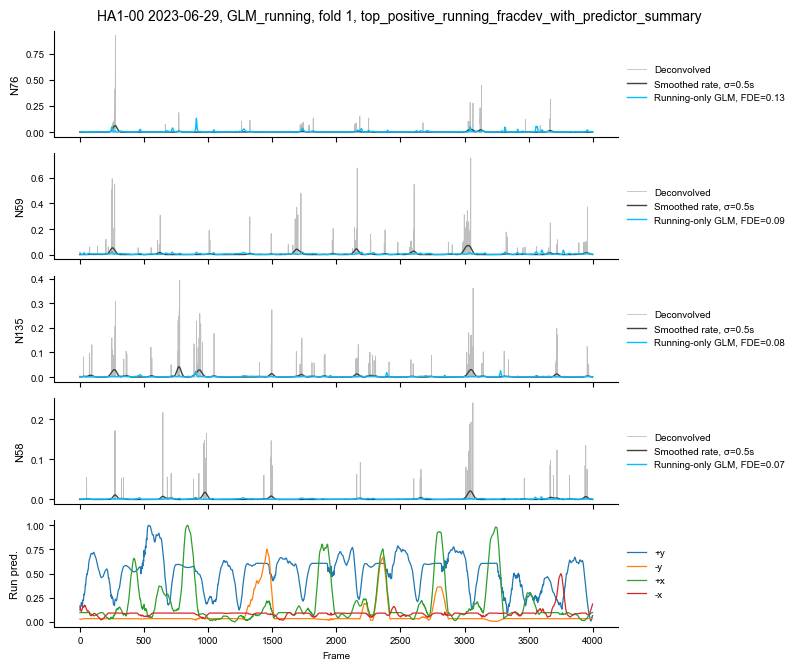

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


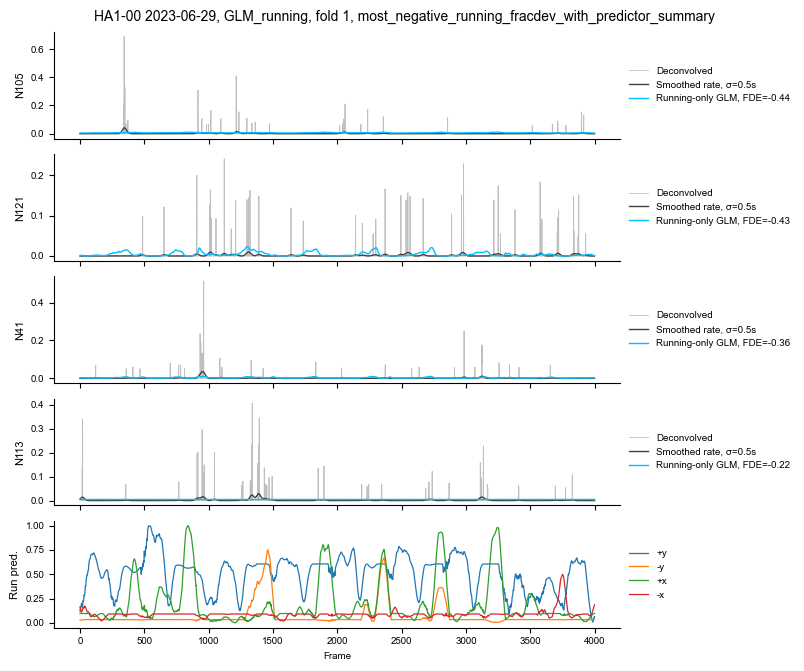

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_with_predictor_summary_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


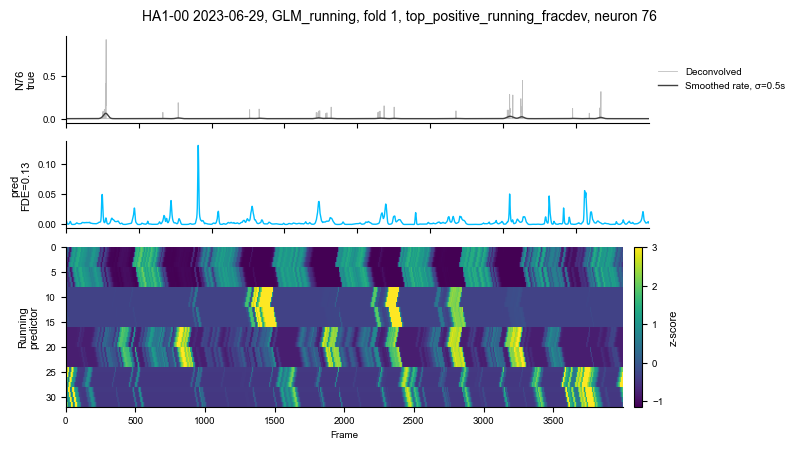

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\top_positive_running_fracdev_heatmap_N76_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


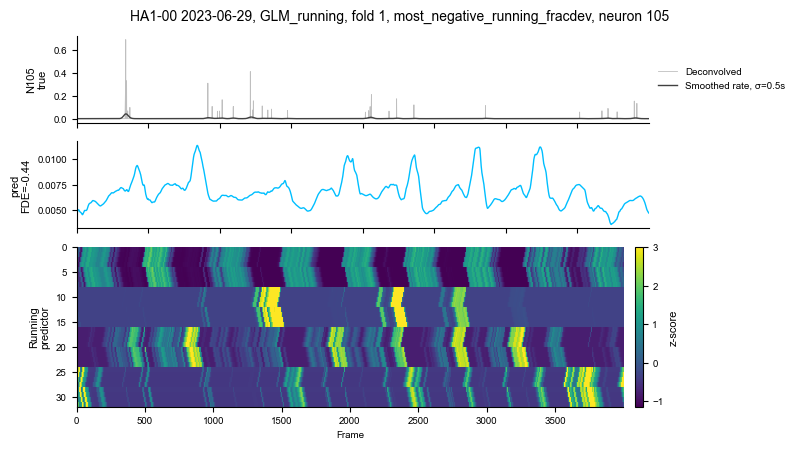

Saved: W:\Connie/results\Bassi2025\glm_coupling/example_predictions_running_predictors\most_negative_running_fracdev_heatmap_N105_HA1-00_2023-06-29_GLM_running_fold1_0to3999.pdf


In [82]:
# Plot running-only GLM predictions, true deconvolved activity, smoothed event rate, and running predictors
# Assumptions:
# - behav_big_matrix.mat contains variable "behav_big_matrix" with shape predictors x frames
# - combined_response.mat contains "combined_response" with shape neurons x frames
# - model y_pred has shape frames x neurons
# - frac_dev_expl has shape neurons
# - response/predictor matrices are from the same fold/test directory

import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Settings
# -----------------------------

example_dataset = mouse_dates_keys[4]  # or set manually, e.g. 'HA11-1R_2023-05-05'
animalID, date = example_dataset.split('_')

fold_number = 0
model_type = 'GLM_running'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
path = os.path.join(save_directory, f"VR_{fold_number + 1}/test")

print("Loading from:", path)

# -----------------------------
# Load model output
# -----------------------------

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()
y_pred = np.asarray(fold_output['y_pred'])

# -----------------------------
# Load response and behavior
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = np.asarray(response['combined_response'])

behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = np.asarray(behav['behav_the_matrix'])

# -----------------------------
# Load raw velocity
# -----------------------------

velocity_file = scipy.io.loadmat(os.path.join(path, 'velocity.mat'))
velocity = velocity_file['velocity'] # expected shape: 2 x frames

x_velocity_raw = velocity[0, :]
y_velocity_raw = velocity[1, :]

pos_x_velocity_raw = np.maximum(x_velocity_raw, 0)
neg_x_velocity_raw = np.maximum(-x_velocity_raw, 0)

pos_y_velocity_raw = np.maximum(y_velocity_raw, 0)
neg_y_velocity_raw = np.maximum(-y_velocity_raw, 0)

print("velocity shape, x/y x frames:", velocity.shape)


supp_figure_dir = f'{save_results}/example_predictions_running_predictors'
os.makedirs(supp_figure_dir, exist_ok=True)

# Change these if desired
n_examples = 4
plot_windows = [(0, 1000), (1000, 2000), (2000, 3000)]
make_heatmaps = True

# Smoothed rate trace settings
plot_smoothed_rate = True
imaging_rate_hz = 30.4791
smooth_sigma_sec = 0.5
smooth_sigma_frames = smooth_sigma_sec * imaging_rate_hz

# -----------------------------
# Helper functions
# -----------------------------

def zscore_for_display(x, axis=1, eps=1e-12):
    """
    Display-only z-score.
    For predictors x frames, use axis=1 to z-score each predictor over time.
    """
    x = x.astype(float).copy()
    mu = np.nanmean(x, axis=axis, keepdims=True)
    sigma = np.nanstd(x, axis=axis, keepdims=True)
    sigma[sigma < eps] = 1.0
    return (x - mu) / sigma


def minmax_for_display(x, eps=1e-12):
    """
    Display-only min-max scaling to 0-1.
    """
    x = x.astype(float).copy()
    x = x - np.nanmin(x)
    denom = np.nanmax(x)
    if denom < eps:
        denom = 1.0
    return x / denom


def plot_neurons_with_running_summary(neuron_ids, frame_start, frame_end, label):
    """
    Plot true deconvolved activity, smoothed deconvolved rate,
    running-only prediction, and a compact running predictor magnitude trace.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    n_rows = len(neuron_ids) + 1

    fig, axs = plt.subplots(
        n_rows,
        1,
        figsize=(8, 1.35 * n_rows),
        sharex=True
    )

    if n_rows == 1:
        axs = [axs]

    for i, neuron_idx in enumerate(neuron_ids):
        ax = axs[i]

        true_y = response_matrix[neuron_idx, frames]
        pred_y = y_pred[frames, neuron_idx]

        ax.plot(
            frames,
            true_y,
            color=[0.75, 0.75, 0.75],
            linewidth=0.6,
            label='Deconvolved'
        )

        if plot_smoothed_rate:
            true_rate = gaussian_filter1d(
                true_y.astype(float),
                sigma=smooth_sigma_frames,
                mode='nearest'
            )

            ax.plot(
                frames,
                true_rate,
                color=[0.25, 0.25, 0.25],
                linewidth=1.0,
                label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
            )

        ax.plot(
            frames,
            pred_y,
            color='deepskyblue',
            linewidth=1.0,
            label=f'Running-only GLM, FDE={frac_dev_expl[neuron_idx]:.2f}'
        )

        ax.set_ylabel(f'N{neuron_idx}', fontsize=8)
        ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Running predictor summary
    ax = axs[-1]

    for group_name, group_trace in running_group_summaries.items():
        ax.plot(
            frames,
            group_trace[frames],
            linewidth=0.9,
            label=group_name
        )

    ax.set_ylabel('Run pred.\ngroups', fontsize=8)

    # ax.plot(
    #     frames,
    #     running_summary_display[frames],
    #     color=[0.2, 0.2, 0.2],
    #     linewidth=0.9,
    #     label='Running predictor magnitude'
    # )

    ax.set_ylabel('Run pred.', fontsize=8)
    ax.set_xlabel('Frame')
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


def plot_neuron_with_running_predictor_heatmap(neuron_idx, frame_start, frame_end, label):
    """
    Plot one neuron with true activity, optional smoothed rate, prediction,
    and all 32 running predictors as a heatmap.
    """
    frames = np.arange(
        frame_start,
        min(frame_end, response_matrix.shape[1], y_pred.shape[0], running_predictors.shape[1])
    )

    pred_display = zscore_for_display(running_predictors[:, frames], axis=1)

    # Optional clipping makes the heatmap easier to view
    pred_display = np.clip(pred_display, -3, 3)

    fig, axs = plt.subplots(
        3,
        1,
        figsize=(8, 4.5),
        sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 2.2]}
    )

    true_y = response_matrix[neuron_idx, frames]

    axs[0].plot(
        frames,
        true_y,
        color=[0.75, 0.75, 0.75],
        linewidth=0.6,
        label='Deconvolved'
    )

    if plot_smoothed_rate:
        true_rate = gaussian_filter1d(
            true_y.astype(float),
            sigma=smooth_sigma_frames,
            mode='nearest'
        )

        axs[0].plot(
            frames,
            true_rate,
            color=[0.25, 0.25, 0.25],
            linewidth=1.0,
            label=f'Smoothed rate, σ={smooth_sigma_sec:.1f}s'
        )

        axs[0].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)

    axs[0].set_ylabel(f'N{neuron_idx}\ntrue', fontsize=8)

    axs[1].plot(
        frames,
        y_pred[frames, neuron_idx],
        color='deepskyblue',
        linewidth=1.0
    )
    axs[1].set_ylabel(f'pred\nFDE={frac_dev_expl[neuron_idx]:.2f}', fontsize=8)

    im = axs[2].imshow(
        pred_display,
        aspect='auto',
        interpolation='nearest',
        extent=[frames[0], frames[-1], running_predictors.shape[0], 0]
    )

    axs[2].set_ylabel('Running\npredictor', fontsize=8)
    axs[2].set_xlabel('Frame')

    cbar = plt.colorbar(im, ax=axs[2], fraction=0.025, pad=0.02)
    cbar.set_label('z-score', fontsize=8)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'{animalID} {date}, {model_type}, fold {fold_number + 1}, {label}, neuron {neuron_idx}',
        fontsize=10
    )

    plt.tight_layout()

    save_path = os.path.join(
        supp_figure_dir,
        f'{label}_heatmap_N{neuron_idx}_{animalID}_{date}_{model_type}_fold{fold_number + 1}_{frame_start}to{frames[-1]}.pdf'
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Load data
# -----------------------------

response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']  # neurons x frames

pred_file = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
running_predictors = pred_file['behav_big_matrix']  # predictors x frames

model_output = results_pre[example_dataset]['model_output_running_active']
fold_output = model_output[fold_number]

y_pred = fold_output['y_pred']  # frames x neurons
frac_dev_expl = np.asarray(fold_output['frac_dev_expl']).squeeze()

print("Path:", path)
print("response_matrix shape, neurons x frames:", response_matrix.shape)
print("y_pred shape, frames x neurons:", y_pred.shape)
print("running_predictors shape, predictors x frames:", running_predictors.shape)
print("frac_dev_expl shape:", frac_dev_expl.shape)
print(f"Smoothed rate sigma: {smooth_sigma_sec} sec = {smooth_sigma_frames:.2f} frames")

# -----------------------------
# Basic shape checks
# -----------------------------

assert response_matrix.shape[0] == y_pred.shape[1], (
    f"Neuron mismatch: response has {response_matrix.shape[0]} neurons, "
    f"y_pred has {y_pred.shape[1]} neurons"
)

# This can differ slightly if model dropped edge frames, so do not assert.
if response_matrix.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: frame mismatch. response has {response_matrix.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

if running_predictors.shape[1] != y_pred.shape[0]:
    print(
        f"Warning: predictor frame mismatch. running_predictors has {running_predictors.shape[1]} frames, "
        f"y_pred has {y_pred.shape[0]} frames"
    )

# -----------------------------
# Make display-only predictor summary
# -----------------------------

# Z-score each predictor over time, then summarize absolute predictor activity
running_pred_z = zscore_for_display(running_predictors, axis=1)
predictor_groups = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}
# Z-score each predictor over time for display only
running_pred_z = zscore_for_display(running_predictors, axis=1)

# Predictor order based on MATLAB construction:
# +y retro, +y prospective, -y retro, -y prospective,
# +x retro, +x prospective, -x retro, -x prospective
predictor_groups_8 = {
    '+y retro': np.arange(0, 4),
    '+y pro':   np.arange(4, 8),
    '-y retro': np.arange(8, 12),
    '-y pro':   np.arange(12, 16),
    '+x retro': np.arange(16, 20),
    '+x pro':   np.arange(20, 24),
    '-x retro': np.arange(24, 28),
    '-x pro':   np.arange(28, 32),
}

# More compact grouping by direction/sign, collapsing retro + prospective together
predictor_groups_4 = {
    '+y': np.arange(0, 8),
    '-y': np.arange(8, 16),
    '+x': np.arange(16, 24),
    '-x': np.arange(24, 32),
}

# Choose which grouping to plot
predictor_groups_to_plot = predictor_groups_4
# predictor_groups_to_plot = predictor_groups_8

running_group_summaries = {}

for group_name, group_idx in predictor_groups_to_plot.items():
    group_trace = np.nanmean(np.abs(running_pred_z[group_idx, :]), axis=0)
    running_group_summaries[group_name] = minmax_for_display(group_trace)
# running_summary = np.nanmean(np.abs(running_pred_z), axis=0)
# running_summary_display = minmax_for_display(running_summary)

# -----------------------------
# Select neurons
# -----------------------------

top_positive_neurons = np.argsort(frac_dev_expl)[::-1][:n_examples]
most_negative_neurons = np.argsort(frac_dev_expl)[:n_examples]

print("\nTop positive running FDE neurons:")
for n in top_positive_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

print("\nMost negative running FDE neurons:")
for n in most_negative_neurons:
    print(f"Neuron {n}: FDE = {frac_dev_expl[n]:.3f}")

# -----------------------------
# Make plots
# -----------------------------
plot_windows = [(0,4000)]
for frame_start, frame_end in plot_windows:
    plot_neurons_with_running_summary(
        top_positive_neurons,
        frame_start,
        frame_end,
        label='top_positive_running_fracdev_with_predictor_summary'
    )

    plot_neurons_with_running_summary(
        most_negative_neurons,
        frame_start,
        frame_end,
        label='most_negative_running_fracdev_with_predictor_summary'
    )

# Optional heatmaps for one top positive and one most negative neuron
if make_heatmaps:
    for frame_start, frame_end in plot_windows[:1]:
        plot_neuron_with_running_predictor_heatmap(
            top_positive_neurons[0],
            frame_start,
            frame_end,
            label='top_positive_running_fracdev'
        )

        plot_neuron_with_running_predictor_heatmap(
            most_negative_neurons[0],
            frame_start,
            frame_end,
            label='most_negative_running_fracdev'
        )

V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_running/VR_1/test
(385, 22956)
Plotting neurons: [282 299]


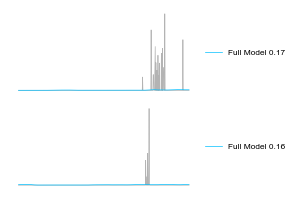

Plotting neurons: [282 299]


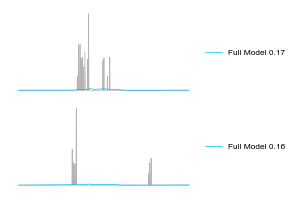

Plotting neurons: [282 299]


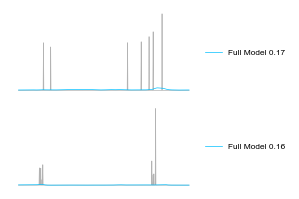

In [92]:
# PLOT EXAMPLE NEURON PREDICTIONS VS TRUE DATA FOR BOTH MODELS FOR FOLD 1
import scipy
import os
import matplotlib.pyplot as plt
import numpy as np

plotter.default_colors_model_type = {
    'full': 'deepskyblue',
    'behav':  'mediumvioletred'} #cornflowerblue #palevioletred

example_dataset = mouse_dates_keys #[mouse_dates_keys[0]] #['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')

supp_figure_dir = f'{save_results}/example_predictions'
os.makedirs(supp_figure_dir, exist_ok=True)

#find robust neurons based on pre or passive

fold_number = 0
model_type = 'GLM_running' #'pre' or 'passive'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/{model_type}/'
model_output_all = results_pre[example_dataset[0]]['model_output_running_active']
# model_output_behav = results_pre[example_dataset[0]]['model_output_behav']

#find neurons based on pre
frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
# frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
# frac_dev_expl_behav = model_output_behav[fold_number]['frac_dev_expl']

# 1️⃣ Set thresholds
min_diff = 0.1         # minimum difference between full and behav model
min_frac_expl = 0.1     # minimum overall fraction explained
min_behav_frac = 0.0    # minimum fraction explained for behavior-only model

# 2️⃣ Mask neurons that satisfy all criteria
# mask = (frac_dev_expl_diff >= min_diff) & \
#     (frac_dev_expl >= min_frac_expl) & \
#     (frac_dev_expl_behav > min_behav_frac)

path = os.path.join(save_directory, "VR_{}/test".format(fold_number+1))
print(path)
# Load actual response data
response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']
# response_matrix[response_matrix > 0.05] = 1 #binarized result
response_matrix = response_matrix[:,:]
print(response_matrix.shape)

corrs = [np.corrcoef(model_output_all[fold_number]['y_pred'][:, i], response_matrix[i])[0, 1]
        for i in range(response_matrix.shape[0])]

# Handle any NaNs (e.g., if no variance in spike train)
correlations = np.nan_to_num(corrs, nan=0.0)

# Sort neuron indices by correlation (descending)
sorted_corr_indices = np.argsort(correlations)[::-1]
sorted_corr_values = correlations[sorted_corr_indices]
# robust_mask = (frac_dev_expl_diff > 0.05) & (correlations > 0.3)

# 3️⃣ Get indices of top neurons (sorted by frac_dev_expl within mask)
# top_indices = np.argsort(frac_dev_expl[robust_mask])[::-1]
top_indices = np.argsort(frac_dev_expl)[::-1]  # Just sort by frac_dev_expl without masking for this example

# 4️⃣ Map back to original indices
selected_neurons = top_indices #np.where(mask)[0][top_indices]
sorted_indices = selected_neurons

#load behav matrix to have some sort of trial structure
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix'] #7/8 are sounds

# Example neuron IDs to plot (replace with your specific neuron IDs)
# neuronIDs = np.random.choice(response_matrix.shape[0],4, replace = False)#[0, 1, 2, 3]  # Example list of neuron IDs
# Sort neuron IDs based on frac_dev_expl (descending)
# frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
# frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
# sorted_indices = np.argsort(frac_dev_expl_diff)[::-1]  # descending order
neuronIDs = sorted_indices[:2]  # Take top 4 [:4]
ranges = [range(i, i+500) for i in range(0, 3000, 1000)]
for frames in ranges: #[range(0,2000), range(2000,4000), range(4000,6000), range(6000,8000)]: #ranges: #
    print("Plotting neurons:", neuronIDs)
    # Create subplots for each neuron
    fig, axs = plt.subplots(len(neuronIDs), 1, figsize=(3,2), sharex=True) #(4,3) figsize=(2.3,.7)
    # Plot each neuron's y_pred for both models
    for i, neuronID in enumerate(neuronIDs):
        # Extract y_pred data for neuronID from model_output_all and model_output_behav
        real_y = response_matrix[neuronID,frames] #
        y_pred_model1 = model_output_all[fold_number]['y_pred'][frames, neuronID]
        # y_pred_model_behav = model_output_behav[fold_number]['y_pred'][frames, neuronID]
        # Plot y_pred for neuronID from both models in the i-th subplot
        # axs[i].plot(behav_matrix[7,frames],color = [0.9, 0.9, 0.9 ] , label='Sound Onset 1')
        # axs[i].plot(behav_matrix[8,frames],color = [0.8, 0.8, 0.8 ] , label='Sound Onset 2')
        axs[i].plot(real_y,color = [0.7, 0.7, 0.7 ] , linewidth=.5) #, label='Deconvolved'
        axs[i].plot(y_pred_model1, label=f"Full Model {model_output_all[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['full'] , linewidth=.5) #[0.4, 0.4, 1 ]
        # axs[i].plot(y_pred_model_behav,label=f"Partial Model {model_output_behav[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['behav'], linewidth=.5) #[0.8, 0.5, 1]
        # Set title and labels for the subplot
        # axs[i].set_title(f'Neuron {neuronID} ') # Comparison between Coupling and no Coupling Model
        # axs[i].set_xlabel('Frames')
        axs[i].set_ylabel('Prediction Value')

        # remove box for each subplot
        axs[i].spines['top'].set_visible(False)
        axs[i].spines['right'].set_visible(False)
        # axs[i].spines['bottom'].set_visible(False)
        # axs[i].spines['left'].set_visible(False)
        axs[i].axis('off')
        # Add legend to the subplot
        axs[i].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)
    # Adjust layout and display
    plt.tight_layout()
    os.chdir(supp_figure_dir)
    plt.savefig(f'ex_neurons_{neuronIDs}_{animalID}_{date}_{model_type}_fold{fold_number}_{frames[0]}to{frames[-1]}.pdf')
    plt.show()